<a href="https://colab.research.google.com/github/iandrukhiv-cell/addressbook-python/blob/main/Module2Task.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Модуль 2. Аналітика клієнтських даних і прогнозування відтоку (Telco Customer Churn)**

**Indian Telecom Customer Churn Dataset** — це набір даних для задач **прогнозування відтоку клієнтів (churn prediction)** та побудови **стратегій утримання (retention strategies)** у контексті індійського телеком-ринку. Він містить **10 000+ записів** (реалістично змодельованих “під реальний світ”) про клієнтів: їх **демографію**, **поведінку користування послугами**, **тарифні/підписні параметри**, а також **платіжні та витратні характеристики**.

https://www.kaggle.com/datasets/kiranmehta1/indian-telecom-customer-churn-prediction-dataset

## Структура файлів (5 CSV)

Набір включає кілька версій даних, що відображають типову логіку підготовки даних: **сирі дані -> очищення/обробка -> навчальний датасет**.

1. **`indian_customers_for_training.csv`**
   *Розмічений тренувальний набір* із **цільовою змінною** та **19 ознаками** для навчання моделей машинного навчання.

2. **`indian_customers_original.csv`**
   *Сирі дані до препроцесингу.* Дані **10 000 клієнтів**. Використовується для повного циклу підготовки: обробка пропусків, перетворення категорій, перевірки якості.

3. **`indian_customers_training.csv`**
   *Очищений та оброблений training-ready набір.* У ньому вже зменшено шум, виправлено типи, стандартизовано значення категорій та підготовлено дані до моделювання. Можна використовувати для порівняння із підготовленим самостійно набором даних.

4. **`indian_telecom_customers.csv`**
   *Повний файл з усіма записами клієнтів і всіма доступними ознаками.* Може слугувати “основною таблицею” для EDA, інженерії ознак та побудови різних варіантів вибірок. Можна використовувати для порівняння із підготовленим самостійно набором даних.

5. **`subscription_data.csv`**
   *Історичні дані підписки та білінгу* для **10 000 клієнтів**. Це важливий компонент для сценаріїв, де потрібно:

   * агрегувати історію по клієнту (середні/суми/тенденції),
   * будувати “поведінкові” ознаки,
   * поєднувати основний профіль клієнта з фінансовою історією.


**В наборі даних є декілька таблиць даних з різним рівнем обробки даних. Необхідно проаналізувати зміст цих таблиць та вирішити з якою з них працювати далі.**


## Ознаки (Features / Columns): що саме описують

### Демографія

Цей блок описує “хто клієнт” і його контекст:

* **Age** — вік (може корелювати зі стилем споживання та лояльністю).
* **Gender** — стать (часто потребує коректної обробки як категорії).
* **City** — місто (просторові/соціально-економічні відмінності можуть впливати на churn).
* **Dependents** — наявність утриманців/залежних (побічно може впливати на стабільність підписки).
* **Profession** — професія/сфера зайнятості (зазвичай категоріальна ознака з кількома класами).

### Послуги та використання (Services & Usage)

Цей блок описує “як клієнт користується сервісом” і наскільки він “вбудований” у оператора:

* **Telecom Operator** — оператор зв’язку: **Airtel, Jio, Vi, BSNL**.
  Це важлива категорійна ознака, бо політики тарифів/якість мережі/покриття можуть бути різними.
* **Plan Type** — тип плану: **Prepaid / Postpaid**.
  Часто суттєво впливає на churn: prepaid зазвичай легше змінюють, postpaid можуть мати інші патерни.
* **Tenure** — тривалість користування (місяці з оператором).
  Це одна з найсильніших ознак у churn-задачах: короткий tenure часто означає підвищений ризик.
* **Customer Support Calls** — кількість звернень до підтримки.
  Високе значення може бути сигналом проблем (якість зв’язку/рахунки/сервіс) і зростання ризику churn.
* **Usage Patterns / Usage Patterns** — узагальнений блок/колонки про патерни споживання (інтенсивність, частота тощо).
  У реальних задачах сюди відносять дзвінки, SMS, data usage, пікові навантаження — і це майже завжди ключові предиктори.

### Білінг та платежі (Billing)

Фінансовий блок описує “скільки і як платить клієнт”:

* **Monthly Charges** — щомісячні нарахування.
* **Total Spend** — сукупні витрати за період (часто пов’язані з tenure, тож важливо уникати некоректних інтерпретацій).
* **Payment Method** — метод оплати: **UPI, Net Banking, Credit Card, Wallet**.


## Цільова змінна (Target)

* **Churn (Yes/No)** — чи відмовився клієнт від послуг оператора.
  Це **бінарна класифікація**, де зазвичай важливі не тільки accuracy, а й **recall/precision для класу “Yes”**, оскільки саме “відтік” часто є меншою часткою і бізнесово значущим.




## План аналізу

1. **Групування даних**.

2. **Інженерія ознак** і перетворення.

3. **EDA** та візуалізації.





#**Групування даних**

**Мета** — отримати **надійний** і **зрозумілий** датафрейм на рівні клієнта (1 рядок = 1 клієнт), з правильно сформованою цільовою ознакою відтоку та перевіреною якістю злиття. Валідація `merge` (кардинальність/унікальність/очікувані розміри) захищає від помилок, а базові перевірки, статистики, викиди та робота з пропусками роблять подальші висновки стабільними.

**План**
1. Завантаження та огляд структури даних.
2. Перетворення типів і базова нормалізація категорій (наприклад, Yes/No), формування цільової ознаки відтоку.
3. Агрегації та підготовка проміжних таблиць за необхідності.
4. Об’єднання таблиць у один customer-level датафрейм за необхідності.
5. Перевірка якості (shape/dtypes/missing/duplicates), базові статистики, виявлення викидів та заповнення пропусків.

**Результат заняття:** підготовлений customer-level датафрейм (наприклад, `df_customer_imp`), готовий для інженерії ознак і подальшого аналізу.







Підключення бібліотек для завантаження даних з Kaggle

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("kiranmehta1/indian-telecom-customer-churn-prediction-dataset")

print("Path to dataset files:", path)

100%|██████████| 1.92M/1.92M [00:00<00:00, 84.3MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/kiranmehta1/indian-telecom-customer-churn-prediction-dataset/versions/1


In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import re

import matplotlib.pyplot as plt
import seaborn as sns



pd.set_option("display.max_columns", 200)   # або None — без обмеження
pd.set_option("display.width", 140)         # ширина рядка у символах
pd.set_option("display.max_colwidth", 50)   # ширина вмісту комірки (None — без обрізання)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/root/.cache/kagglehub/datasets/kiranmehta1/indian-telecom-customer-churn-prediction-dataset/versions/1'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/root/.cache/kagglehub/datasets/kiranmehta1/indian-telecom-customer-churn-prediction-dataset/versions/1/indian_telecom_customers.csv
/root/.cache/kagglehub/datasets/kiranmehta1/indian-telecom-customer-churn-prediction-dataset/versions/1/subscription_data.csv
/root/.cache/kagglehub/datasets/kiranmehta1/indian-telecom-customer-churn-prediction-dataset/versions/1/indian_customers_training.csv
/root/.cache/kagglehub/datasets/kiranmehta1/indian-telecom-customer-churn-prediction-dataset/versions/1/indian_customers_original.csv
/root/.cache/kagglehub/datasets/kiranmehta1/indian-telecom-customer-churn-prediction-dataset/versions/1/indian_customers_for_training.csv


# Завантаження даних

Завантаження таблиць даних та базові перевірки

In [3]:
path = "/root/.cache/kagglehub/datasets/kiranmehta1/indian-telecom-customer-churn-prediction-dataset/versions/1/"

paths = {
    "indian_customers_original":      path + "indian_customers_original.csv",
    "indian_telecom_customers":       path + "indian_telecom_customers.csv",
    "indian_customers_for_training":  path + "indian_customers_for_training.csv",
    "indian_customers_training":      path + "indian_customers_training.csv",
    "subscription_data":              path + "subscription_data.csv",
}

dfs = {name: pd.read_csv(path) for name, path in paths.items()}

# Швидка перевірка розмірів
pd.DataFrame({k: {"rows": v.shape[0], "cols": v.shape[1]} for k, v in dfs.items()}).T




,rows,cols
indian_customers_original,10000,39
indian_telecom_customers,15000,39
indian_customers_for_training,10000,20
indian_customers_training,15000,20
subscription_data,10000,11


In [4]:
dfs.keys()

dict_keys(['indian_customers_original', 'indian_telecom_customers', 'indian_customers_for_training', 'indian_customers_training', 'subscription_data'])

In [5]:
print("customer data original:", dfs['indian_customers_original'].shape)

display(dfs['indian_customers_original'])
display(dfs['indian_customers_original'].info())


customer data original: (10000, 39)


,customer_id,name,phone,gender,age,city,state,pincode,city_tier,profession,annual_income_lakhs,is_married,has_children,num_dependents,operator,plan_type,monthly_charges,is_prepaid,tenure_months,total_charges,data_usage_gb,voice_minutes,sms_count,has_internet,has_ott_bundle,payment_method,payment_delays_last_6m,primary_language,prefers_regional_support,support_calls_last_month,network_satisfaction,price_satisfaction,overall_satisfaction,competitor_offers_received,price_sensitivity_score,is_festival_season,monsoon_impact,churn_probability,churn
0,IND000001,Arjun Bhatt,918332181960,Male,37,Indore,Maharashtra,198246,Tier 2,Student,2.00,True,True,1,Jio,Basic,282,True,32,9024,22,298,93,True,True,UPI,0,Punjabi,True,0,1,3,2,1,4,False,False,0.683,Yes
1,IND000002,Kavya Bose,918940781618,Female,44,Kolkata,West Bengal,969693,Tier 1,Government Employee,26.18,True,False,2,Airtel,Standard,322,True,27,8694,44,50,94,True,True,Debit Card,0,English,False,0,4,2,5,2,3,False,False,0.498,Yes
2,IND000003,Ramesh Desai,917832764835,Male,25,Bhopal,Maharashtra,340174,Tier 2,Business Owner,7.09,False,False,0,BSNL,Standard,504,True,2,1008,27,126,44,True,False,Credit Card,1,English,False,1,6,4,9,5,8,False,False,0.657,Yes
3,IND000004,Geeta Tiwari,919532871012,Female,43,Faridabad,Maharashtra,930555,Tier 2,Government Employee,17.33,True,True,6,Airtel,Premium,882,False,7,6174,29,480,11,True,True,UPI,0,Hindi,False,0,6,2,9,0,5,False,False,0.489,No
4,IND000005,Shubham Das,917252880957,Male,26,Mumbai,Maharashtra,217301,Tier 1,Private Employee,9.15,False,False,0,Vi,Standard,421,True,7,2947,51,383,17,True,True,Net Banking,1,Hindi,False,0,2,9,10,3,9,False,False,0.266,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,IND009996,Vidya Nair,917283879136,Female,27,Kanpur,Uttar Pradesh,727121,Tier 1,Others,24.25,False,False,1,Jio,Standard,593,True,1,593,40,143,13,True,True,Debit Card,0,Hindi,True,2,1,5,4,0,3,False,False,0.759,No
9996,IND009997,Tanya Srivastava,918676671709,Female,33,Chennai,Tamil Nadu,832775,Tier 1,IT Professional,41.44,True,False,3,Airtel,Premium,896,True,11,9856,25,392,52,False,True,UPI,0,Tamil,False,1,1,8,9,4,5,False,False,0.428,No
9997,IND009998,Rashmi Bose,918847918775,Female,31,Mumbai,Maharashtra,410224,Tier 1,Private Employee,7.93,False,False,0,Jio,Basic,181,False,15,2715,5,182,85,True,False,UPI,0,English,False,0,6,3,9,1,1,False,False,0.273,No
9998,IND009999,Geeta Shah,918341918559,Female,29,Vasai,Maharashtra,673815,Tier 2,Retired,10.46,True,True,2,BSNL,Basic,125,False,20,2500,57,65,84,True,True,Debit Card,0,Hindi,False,1,5,2,10,0,5,False,False,0.243,No


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 39 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   customer_id                 10000 non-null  object 
 1   name                        10000 non-null  object 
 2   phone                       10000 non-null  int64  
 3   gender                      10000 non-null  object 
 4   age                         10000 non-null  int64  
 5   city                        10000 non-null  object 
 6   state                       10000 non-null  object 
 7   pincode                     10000 non-null  int64  
 8   city_tier                   10000 non-null  object 
 9   profession                  10000 non-null  object 
 10  annual_income_lakhs         10000 non-null  float64
 11  is_married                  10000 non-null  bool   
 12  has_children                10000 non-null  bool   
 13  num_dependents              1000

None

In [6]:
print("customer all data :", dfs['indian_telecom_customers'].shape)

display(dfs['indian_telecom_customers'])
display(dfs['indian_telecom_customers'].info())


customer all data : (15000, 39)


,customer_id,name,phone,gender,age,city,state,pincode,city_tier,profession,annual_income_lakhs,is_married,has_children,num_dependents,operator,plan_type,monthly_charges,is_prepaid,tenure_months,total_charges,data_usage_gb,voice_minutes,sms_count,has_internet,has_ott_bundle,payment_method,payment_delays_last_6m,primary_language,prefers_regional_support,support_calls_last_month,network_satisfaction,price_satisfaction,overall_satisfaction,competitor_offers_received,price_sensitivity_score,is_festival_season,monsoon_impact,churn_probability,churn
0,IND000001,Arjun Bhatt,918332181960,Male,37,Indore,Maharashtra,198246,Tier 2,Student,2.00,True,True,1,Jio,Basic,282,True,32,9024,22,298,93,True,True,UPI,0,Punjabi,True,0,1,3,2,1,4,False,False,0.683,Yes
1,IND000002,Kavya Bose,918940781618,Female,44,Kolkata,West Bengal,969693,Tier 1,Government Employee,26.18,True,False,2,Airtel,Standard,322,True,27,8694,44,50,94,True,True,Debit Card,0,English,False,0,4,2,5,2,3,False,False,0.498,Yes
2,IND000003,Ramesh Desai,917832764835,Male,25,Bhopal,Maharashtra,340174,Tier 2,Business Owner,7.09,False,False,0,BSNL,Standard,504,True,2,1008,27,126,44,True,False,Credit Card,1,English,False,1,6,4,9,5,8,False,False,0.657,Yes
3,IND000004,Geeta Tiwari,919532871012,Female,43,Faridabad,Maharashtra,930555,Tier 2,Government Employee,17.33,True,True,6,Airtel,Premium,882,False,7,6174,29,480,11,True,True,UPI,0,Hindi,False,0,6,2,9,0,5,False,False,0.489,No
4,IND000005,Shubham Das,917252880957,Male,26,Mumbai,Maharashtra,217301,Tier 1,Private Employee,9.15,False,False,0,Vi,Standard,421,True,7,2947,51,383,17,True,True,Net Banking,1,Hindi,False,0,2,9,10,3,9,False,False,0.266,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14995,IND014996,Ananya Nair,919187844900,Female,25,Lucknow,Uttar Pradesh,557443,Tier 1,Business Owner,39.83,False,False,0,Airtel,Premium,745,True,24,17880,10,73,30,True,False,UPI,0,Bengali,False,2,5,1,9,3,10,False,False,0.551,No
14996,IND014997,Chitra Shah,918077266399,Female,21,Delhi,Delhi,652873,Tier 1,Farmer,14.01,False,False,0,Vi,Standard,500,True,45,22500,32,91,18,True,True,Net Banking,1,English,False,1,3,2,2,2,6,False,False,0.617,No
14997,IND014998,Sachin Arora,919955444155,Male,33,Aligarh,Maharashtra,162678,Tier 3,Student,3.35,False,False,0,Jio,Basic,143,True,28,4004,47,266,62,True,True,Net Banking,0,English,False,0,4,2,10,1,9,False,False,0.652,Yes
14998,IND014999,Neha Ghosh,918050607459,Female,33,Vadodara,Maharashtra,311495,Tier 2,IT Professional,16.90,False,False,0,Jio,Premium,906,True,5,4530,53,382,52,True,True,Net Banking,1,Tamil,True,1,1,6,6,5,7,False,False,0.728,No


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 39 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   customer_id                 15000 non-null  object 
 1   name                        15000 non-null  object 
 2   phone                       15000 non-null  int64  
 3   gender                      15000 non-null  object 
 4   age                         15000 non-null  int64  
 5   city                        15000 non-null  object 
 6   state                       15000 non-null  object 
 7   pincode                     15000 non-null  int64  
 8   city_tier                   15000 non-null  object 
 9   profession                  15000 non-null  object 
 10  annual_income_lakhs         15000 non-null  float64
 11  is_married                  15000 non-null  bool   
 12  has_children                15000 non-null  bool   
 13  num_dependents              150

None

In [7]:
print("customer data for ML training:", dfs['indian_customers_for_training'].shape)

display(dfs['indian_customers_for_training'])
display(dfs['indian_customers_for_training'].info())


customer data for ML training: (10000, 20)


,gender,SeniorCitizen,Partner,Dependents,tenure,MonthlyCharges,TotalCharges,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Churn
0,Male,0,Yes,Yes,32,282,9024,Yes,No,Fiber optic,No,No,No,No,Yes,Yes,Two year,Yes,Electronic check,Yes
1,Female,0,Yes,Yes,27,322,8694,Yes,No,Fiber optic,No,No,No,No,Yes,Yes,Two year,No,Bank transfer (automatic),Yes
2,Male,0,No,No,2,504,1008,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,No,Credit card (automatic),Yes
3,Female,0,Yes,Yes,7,882,6174,Yes,No,Fiber optic,Yes,Yes,Yes,Yes,Yes,Yes,One year,Yes,Electronic check,No
4,Male,0,No,No,7,421,2947,Yes,No,Fiber optic,No,No,No,No,Yes,Yes,One year,Yes,Bank transfer (automatic),No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,Female,0,No,Yes,1,593,593,Yes,No,Fiber optic,No,No,No,No,Yes,Yes,Month-to-month,No,Bank transfer (automatic),No
9996,Female,0,Yes,Yes,11,896,9856,Yes,No,Fiber optic,Yes,Yes,Yes,Yes,Yes,Yes,One year,Yes,Electronic check,No
9997,Female,0,No,No,15,181,2715,Yes,No,No,No,No,No,No,No,No,One year,Yes,Electronic check,No
9998,Female,0,Yes,Yes,20,125,2500,Yes,No,Fiber optic,No,No,No,No,Yes,Yes,Two year,No,Bank transfer (automatic),No


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   gender            10000 non-null  object
 1   SeniorCitizen     10000 non-null  int64 
 2   Partner           10000 non-null  object
 3   Dependents        10000 non-null  object
 4   tenure            10000 non-null  int64 
 5   MonthlyCharges    10000 non-null  int64 
 6   TotalCharges      10000 non-null  int64 
 7   PhoneService      10000 non-null  object
 8   MultipleLines     10000 non-null  object
 9   InternetService   10000 non-null  object
 10  OnlineSecurity    10000 non-null  object
 11  OnlineBackup      10000 non-null  object
 12  DeviceProtection  10000 non-null  object
 13  TechSupport       10000 non-null  object
 14  StreamingTV       10000 non-null  object
 15  StreamingMovies   10000 non-null  object
 16  Contract          10000 non-null  object
 17  PaperlessBill

None

In [8]:
print("customer data, cleaned and preprocessed:", dfs['indian_customers_training'].shape)

display(dfs['indian_customers_training'])
display(dfs['indian_customers_training'].info())


customer data, cleaned and preprocessed: (15000, 20)


,gender,SeniorCitizen,Partner,Dependents,tenure,MonthlyCharges,TotalCharges,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Churn
0,Male,0,Yes,Yes,32,282,9024,Yes,No,Fiber optic,No,No,No,No,Yes,Yes,Two year,Yes,Electronic check,Yes
1,Female,0,Yes,Yes,27,322,8694,Yes,No,Fiber optic,Yes,Yes,Yes,Yes,Yes,Yes,Two year,No,Bank transfer (automatic),Yes
2,Male,0,No,No,2,504,1008,Yes,No,Fiber optic,No,No,No,Yes,No,No,Month-to-month,No,Credit card (automatic),Yes
3,Female,0,Yes,Yes,7,882,6174,Yes,No,Fiber optic,Yes,Yes,Yes,Yes,Yes,Yes,One year,Yes,Electronic check,No
4,Male,0,No,No,7,421,2947,Yes,No,Fiber optic,No,Yes,No,No,Yes,Yes,One year,Yes,Bank transfer (automatic),No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14995,Female,0,No,No,24,745,17880,Yes,No,DSL,Yes,Yes,Yes,Yes,No,No,Two year,Yes,Electronic check,No
14996,Female,0,No,No,45,500,22500,Yes,No,Fiber optic,No,No,Yes,No,Yes,Yes,Two year,Yes,Bank transfer (automatic),No
14997,Male,0,No,No,28,143,4004,Yes,No,Fiber optic,No,No,No,No,Yes,Yes,Two year,Yes,Bank transfer (automatic),Yes
14998,Female,0,No,No,5,906,4530,Yes,No,Fiber optic,Yes,Yes,Yes,Yes,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),No


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   gender            15000 non-null  object
 1   SeniorCitizen     15000 non-null  int64 
 2   Partner           15000 non-null  object
 3   Dependents        15000 non-null  object
 4   tenure            15000 non-null  int64 
 5   MonthlyCharges    15000 non-null  int64 
 6   TotalCharges      15000 non-null  int64 
 7   PhoneService      15000 non-null  object
 8   MultipleLines     15000 non-null  object
 9   InternetService   15000 non-null  object
 10  OnlineSecurity    15000 non-null  object
 11  OnlineBackup      15000 non-null  object
 12  DeviceProtection  15000 non-null  object
 13  TechSupport       15000 non-null  object
 14  StreamingTV       15000 non-null  object
 15  StreamingMovies   15000 non-null  object
 16  Contract          15000 non-null  object
 17  PaperlessBil

None

In [19]:
# Підсумок всіх завантажених таблиць
pd.DataFrame({k: {"rows": v.shape[0], "cols": v.shape[1]} for k, v in dfs.items()}).T

,rows,cols
indian_customers_original,10000,39
indian_telecom_customers,15000,39
indian_customers_for_training,10000,20
indian_customers_training,15000,20
subscription_data,10000,11


In [9]:
print("Subscription data:", dfs['subscription_data'].shape)

display(dfs['subscription_data'])
display(dfs['subscription_data'].info())


Subscription data: (10000, 11)


,SubscriptionID,CustomerID,CustomerName,Email,City,PlanType,Amount,StartDate,EndDate,Status,PaymentMethod
0,SUB-100000,CUST-29478,Vikram Kulkarni,vikram.kulkarni@example.com,Delhi,Standard,499,2023-06-16,2023-07-16,Active,UPI
1,SUB-100001,CUST-41541,Kiara Malhotra,kiara.malhotra@example.com,Visakhapatnam,Standard,499,2023-04-05,2023-07-04,Active,Wallet
2,SUB-100002,CUST-91250,Arjun Nair,arjun.nair@example.com,Chennai,Basic,199,2023-07-16,2023-10-14,Pending,Net Banking
3,SUB-100003,CUST-71590,Reyansh Saxena,reyansh.saxena@example.com,Bangalore,Enterprise,4999,2023-07-08,2023-10-06,Active,Net Banking
4,SUB-100004,CUST-36595,Neha Reddy,neha.reddy@example.com,Nagpur,Basic,199,2023-08-31,2023-11-29,Expired,UPI
...,...,...,...,...,...,...,...,...,...,...,...
9995,SUB-109995,CUST-88258,Pooja Singh,pooja.singh@example.com,Vadodara,Premium,999,2023-01-30,2024-01-30,Active,Debit Card
9996,SUB-109996,CUST-55353,Aadhya Patel,aadhya.patel@example.com,Pune,Standard,499,2023-07-22,2023-08-21,Active,Net Banking
9997,SUB-109997,CUST-78709,Ananya Kapoor,ananya.kapoor@example.com,Jaipur,Basic,199,2023-07-13,2023-10-11,Active,UPI
9998,SUB-109998,CUST-26330,Vihaan Jain,vihaan.jain@example.com,Indore,Basic,199,2023-07-26,2023-10-24,Active,Wallet


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   SubscriptionID  10000 non-null  object
 1   CustomerID      10000 non-null  object
 2   CustomerName    10000 non-null  object
 3   Email           10000 non-null  object
 4   City            10000 non-null  object
 5   PlanType        10000 non-null  object
 6   Amount          10000 non-null  int64 
 7   StartDate       10000 non-null  object
 8   EndDate         10000 non-null  object
 9   Status          10000 non-null  object
 10  PaymentMethod   10000 non-null  object
dtypes: int64(1), object(10)
memory usage: 859.5+ KB


None

# Базовий профіль таблиць: розмір, пропуски, дублі, типи

Цей блок дає “паспорт” кожної таблиці:
- кількість рядків/стовпців
- кількість повних дублікатів рядків
- кількість пропусків (в ідеалі 0)
- пам’ять (MB)
- скільки числових / текстових / булевих ознак

In [20]:
# Функція візуалізації таблиці з характеристиками
def table_profile(df, name="df"):
    print(f"=== {name} ===")
    print(f"Shape: {df.shape[0]} рядків × {df.shape[1]} стовпців")
    print(f"Дублікати: {df.duplicated().sum()}")
    print(f"Пам'ять: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
    print(f"\nТипи ознак:")
    print(f"  Числові:    {df.select_dtypes(include='number').shape[1]}")
    print(f"  Текстові:   {df.select_dtypes(include='object').shape[1]}")
    print(f"  Булеві:     {df.select_dtypes(include='bool').shape[1]}")
    print(f"  Дати:       {df.select_dtypes(include='datetime').shape[1]}")

    missing = df.isnull().sum()
    missing = missing[missing > 0]
    if len(missing) > 0:
        print(f"\nПропуски:")
        for col, cnt in missing.items():
            print(f"  {col}: {cnt} ({cnt/len(df)*100:.1f}%)")
    else:
        print(f"\n✅ Пропусків немає")
    print()

for name, df in dfs.items():
    table_profile(df, name)

=== indian_customers_original ===
Shape: 10000 рядків × 39 стовпців
Дублікати: 0
Пам'ять: 7.98 MB

Типи ознак:
  Числові:    19
  Текстові:   12
  Булеві:     8
  Дати:       0

✅ Пропусків немає

=== indian_telecom_customers ===
Shape: 15000 рядків × 39 стовпців
Дублікати: 0
Пам'ять: 11.97 MB

Типи ознак:
  Числові:    19
  Текстові:   12
  Булеві:     8
  Дати:       0

✅ Пропусків немає

=== indian_customers_for_training ===
Shape: 10000 рядків × 20 стовпців
Дублікати: 4
Пам'ять: 8.47 MB

Типи ознак:
  Числові:    4
  Текстові:   16
  Булеві:     0
  Дати:       0

✅ Пропусків немає

=== indian_customers_training ===
Shape: 15000 рядків × 20 стовпців
Дублікати: 10
Пам'ять: 12.72 MB

Типи ознак:
  Числові:    4
  Текстові:   16
  Булеві:     0
  Дати:       0

✅ Пропусків немає

=== subscription_data ===
Shape: 10000 рядків × 11 стовпців
Дублікати: 0
Пам'ять: 5.73 MB

Типи ознак:
  Числові:    1
  Текстові:   10
  Булеві:     0
  Дати:       0

✅ Пропусків немає



In [21]:
table_profile(dfs['indian_customers_original'], 'indian_customers_original')

=== indian_customers_original ===
Shape: 10000 рядків × 39 стовпців
Дублікати: 0
Пам'ять: 7.98 MB

Типи ознак:
  Числові:    19
  Текстові:   12
  Булеві:     8
  Дати:       0

✅ Пропусків немає



## Порівняння схем (наборів колонок)

Порівняння таблиць на рівні структури:
- чи однаковий набір колонок у `indian_customers_original` та `indian_telecom_customers`
- чи співпадає схема у двох “training” таблиць
- чи є ознаки, що відсутні/додані між файлами



In [22]:
# Функція порівняння наборів ознак в різних таблицях
def compare_schemas(dfs: dict):
    all_cols = {}
    for name, df in dfs.items():
        all_cols[name] = set(df.columns)

    names = list(all_cols.keys())
    print("=== ПОРІВНЯННЯ КОЛОНОК ===\n")

    for i in range(len(names)):
        for j in range(i+1, len(names)):
            a, b = names[i], names[j]
            only_a = all_cols[a] - all_cols[b]
            only_b = all_cols[b] - all_cols[a]
            common = all_cols[a] & all_cols[b]
            print(f"--- {a} vs {b} ---")
            print(f"  Спільних колонок: {len(common)}")
            if only_a:
                print(f"  Тільки в {a}: {sorted(only_a)}")
            if only_b:
                print(f"  Тільки в {b}: {sorted(only_b)}")
            print()

compare_schemas(dfs)

=== ПОРІВНЯННЯ КОЛОНОК ===

--- indian_customers_original vs indian_telecom_customers ---
  Спільних колонок: 39

--- indian_customers_original vs indian_customers_for_training ---
  Спільних колонок: 1
  Тільки в indian_customers_original: ['age', 'annual_income_lakhs', 'churn', 'churn_probability', 'city', 'city_tier', 'competitor_offers_received', 'customer_id', 'data_usage_gb', 'has_children', 'has_internet', 'has_ott_bundle', 'is_festival_season', 'is_married', 'is_prepaid', 'monsoon_impact', 'monthly_charges', 'name', 'network_satisfaction', 'num_dependents', 'operator', 'overall_satisfaction', 'payment_delays_last_6m', 'payment_method', 'phone', 'pincode', 'plan_type', 'prefers_regional_support', 'price_satisfaction', 'price_sensitivity_score', 'primary_language', 'profession', 'sms_count', 'state', 'support_calls_last_month', 'tenure_months', 'total_charges', 'voice_minutes']
  Тільки в indian_customers_for_training: ['Churn', 'Contract', 'Dependents', 'DeviceProtection', 'Inte

Отже, за структурою таблиці з парними назвами схожі.

## Висновки порівняння схем

- `indian_customers_original` та `indian_telecom_customers` мають **однакові 39 колонок** — це фактично один датасет різного розміру (10k vs 15k рядків)
- `indian_customers_for_training` та `indian_customers_training` мають **однакові 20 колонок** — це навчальні вибірки з іншою структурою (англійські назви колонок)
- `subscription_data` — повністю окрема таблиця, **жодної спільної колонки** з основними таблицями
- Для подальшого аналізу обираємо `indian_customers_original` як основну таблицю — вона має найбільш детальний набір ознак (39 колонок) з зрозумілими назвами

## Описова статистика

### Числові ознаки
Показуємо `mean/std/min/квартилі/max` для числових колонок.

### Булеві ознаки
Для булевих колонок доцільно дивитись частку `True` (середнє значення).

### Категоріальні ознаки
Для категорійних — кількість унікальних значень та топ-значення з частотами.

In [23]:
# Функції описової статистики для порівняння таблиць даних
def numeric_summary(df, name="df"):
    nums = df.select_dtypes(include='number')
    if nums.empty:
        print(f"{name}: числових колонок немає")
        return
    print(f"=== ЧИСЛОВІ ОЗНАКИ: {name} ===")
    display(nums.describe().T.round(2))

def bool_summary(df, name="df"):
    bools = df.select_dtypes(include='bool')
    if bools.empty:
        return
    print(f"\n=== БУЛЕВІ ОЗНАКИ: {name} (частка True) ===")
    display(bools.mean().round(3).to_frame("rate_true"))

numeric_summary(dfs['indian_customers_original'], 'indian_customers_original')
bool_summary(dfs['indian_customers_original'], 'indian_customers_original')

=== ЧИСЛОВІ ОЗНАКИ: indian_customers_original ===


,count,mean,std,min,25%,50%,75%,max
phone,10000.0,9.180055e+11,1.161323e+09,9.160000e+11,9.169956e+11,9.180040e+11,9.190232e+11,9.199999e+11
age,10000.0,3.239000e+01,1.069000e+01,1.800000e+01,2.400000e+01,3.200000e+01,4.000000e+01,7.700000e+01
pincode,10000.0,5.511786e+05,2.591410e+05,1.000090e+05,3.260692e+05,5.542500e+05,7.744588e+05,9.999630e+05
annual_income_lakhs,10000.0,1.649000e+01,1.249000e+01,2.000000e+00,7.090000e+00,1.305000e+01,2.238000e+01,6.747000e+01
num_dependents,10000.0,1.590000e+00,1.750000e+00,0.000000e+00,0.000000e+00,1.000000e+00,3.000000e+00,7.000000e+00
monthly_charges,10000.0,5.455200e+02,4.972900e+02,9.900000e+01,2.380000e+02,4.180000e+02,6.650000e+02,2.999000e+03
tenure_months,10000.0,1.750000e+01,1.767000e+01,1.000000e+00,5.000000e+00,1.200000e+01,2.400000e+01,1.600000e+02
total_charges,10000.0,9.490400e+03,1.555962e+04,1.000000e+02,1.687000e+03,4.532000e+03,1.094400e+04,2.791100e+05
data_usage_gb,10000.0,2.938000e+01,2.087000e+01,1.000000e+00,1.400000e+01,2.500000e+01,3.900000e+01,1.720000e+02
voice_minutes,10000.0,3.019100e+02,2.448800e+02,5.000000e+01,1.210000e+02,2.350000e+02,4.110000e+02,2.403000e+03



=== БУЛЕВІ ОЗНАКИ: indian_customers_original (частка True) ===


,rate_true
is_married,0.491
has_children,0.294
is_prepaid,0.846
has_internet,0.950
has_ott_bundle,0.600
prefers_regional_support,0.525
is_festival_season,0.196
monsoon_impact,0.072


## Висновки описової статистики

- Всі 10 000 рядків повні — пропусків немає
- `age`: середній вік клієнта ~32 роки, діапазон 18–77
- `monthly_charges`: середній місячний платіж ~546, великий розкид (std ~497) — є клієнти з дуже різними тарифами
- `total_charges`: від 100 до ~155 000 — сильна права асиметрія, потребує log-перетворення
- `tenure_months`: медіана ~12 місяців — більшість клієнтів відносно нові
- `churn_probability`: середнє ~0.49 — датасет збалансований по відтоку
- Булеві ознаки: 95% клієнтів мають інтернет, 85% — prepaid тариф, лише 7% зазнали впливу мусону

## Перевірка customer_id / CustomerID та перетин клієнтів

Завдання:
1) визначити, у яких таблицях є колонка ідентифікатора клієнта (`customer_id` або `CustomerID`);
2) перевірити унікальність ID в кожній таблиці;
3) обчислити **перетин** множин клієнтів між таблицями:
- Intersection size
- Coverage A→B (яка частка клієнтів A присутня в B)
- Coverage B→A
- Jaccard (|A∩B| / |A∪B|)

In [24]:
# Функції перевірки customer_id / CustomerID та перетину клієнтів
def check_customer_id(dfs: dict):
    id_cols = {"indian_customers_original": "customer_id",
               "indian_telecom_customers": "customer_id",
               "subscription_data": "CustomerID"}

    print("=== ПЕРЕВІРКА customer_id ===\n")

    id_sets = {}
    for name, col in id_cols.items():
        if name not in dfs:
            continue
        df = dfs[name]
        if col not in df.columns:
            print(f"{name}: колонка '{col}' відсутня")
            continue

        total = len(df)
        unique = df[col].nunique()
        dupes = total - unique
        id_sets[name] = set(df[col].astype(str))

        print(f"{name} [{col}]:")
        print(f"  Всього рядків: {total}")
        print(f"  Унікальних ID: {unique}")
        print(f"  Дублікатів:    {dupes}")
        print()

    print("=== ПЕРЕТИН КЛІЄНТІВ ===\n")
    names = list(id_sets.keys())
    for i in range(len(names)):
        for j in range(i+1, len(names)):
            a, b = names[i], names[j]
            intersection = id_sets[a] & id_sets[b]
            print(f"{a} ∩ {b}: {len(intersection)} спільних клієнтів")

check_customer_id(dfs)

=== ПЕРЕВІРКА customer_id ===

indian_customers_original [customer_id]:
  Всього рядків: 10000
  Унікальних ID: 10000
  Дублікатів:    0

indian_telecom_customers [customer_id]:
  Всього рядків: 15000
  Унікальних ID: 15000
  Дублікатів:    0

subscription_data [CustomerID]:
  Всього рядків: 10000
  Унікальних ID: 9482
  Дублікатів:    518

=== ПЕРЕТИН КЛІЄНТІВ ===

indian_customers_original ∩ indian_telecom_customers: 10000 спільних клієнтів
indian_customers_original ∩ subscription_data: 0 спільних клієнтів
indian_telecom_customers ∩ subscription_data: 0 спільних клієнтів


## Висновки перевірки customer_id

- `indian_customers_original` та `indian_telecom_customers` — ID унікальні, дублікатів немає
- `indian_customers_original` повністю входить у `indian_telecom_customers` (10 000 з 15 000 клієнтів спільні) — це підвибірка одного датасету
- `subscription_data` має 518 дублікатів CustomerID — один клієнт може мати кілька підписок
- `subscription_data` **не перетинається** з основними таблицями за ID — це окрема система з іншими ідентифікаторами, тому об'єднати їх через ID неможливо

➡️ Для аналізу використовуємо `indian_customers_original` як основну таблицю

## Додатково: “training” таблиці — чи це ті самі записи?

У `indian_customers_for_training` та `indian_customers_training` немає customer_id, тому перетин клієнтів обчислити напряму неможливо.
Однак можна перевірити **перетин рядків** (однакові комбінації ознак).
Це відповідає питанню: “чи training-набір — це надмножина smaller training, чи це інша генерація/вибірка?”

In [25]:
# Код перевірки
train = dfs['indian_customers_for_training']
training = dfs['indian_customers_training']

print("=== ПОРІВНЯННЯ TRAINING ТАБЛИЦЬ ===\n")
print(f"indian_customers_for_training: {train.shape}")
print(f"indian_customers_training:     {training.shape}")
print(f"\nСпільних колонок: {len(set(train.columns) & set(training.columns))}")
print(f"Колонки однакові: {sorted(train.columns.tolist()) == sorted(training.columns.tolist())}")

# Перевірка спільного стовпця gender
if 'gender' in train.columns and 'gender' in training.columns:
    print(f"\ngender в for_training: {train['gender'].value_counts().to_dict()}")
    print(f"gender в training:     {training['gender'].value_counts().to_dict()}")

=== ПОРІВНЯННЯ TRAINING ТАБЛИЦЬ ===

indian_customers_for_training: (10000, 20)
indian_customers_training:     (15000, 20)

Спільних колонок: 20
Колонки однакові: True

gender в for_training: {'Female': 5077, 'Male': 4923}
gender в training:     {'Female': 7531, 'Male': 7469}


## Висновки порівняння training таблиць

- Обидві таблиці мають **однакові 20 колонок** — структура ідентична
- `indian_customers_training` більша (15 000 vs 10 000) — це розширена версія
- Розподіл статі схожий в обох таблицях (≈50/50)
- Ці таблиці є **навчальними вибірками з іншою структурою** ніж основний датасет — назви колонок англійські (CamelCase), тому для нашого аналізу **не використовуємо** їх

➡️ Продовжуємо працювати виключно з `indian_customers_original`

Обрати саме **`df_original` (`indian_customers_original.csv`)** для подальшого аналізу доречніше у порівнянні із *_train* наборами.

`df_original` позиціонується як **raw до preprocessing** в описі набору даних. Це важливо, бо саме на цьому етапі коректно:

* виявляти пропуски, неузгоджені категорії, аномальні значення;
* приймати рішення про обробку (impute, фільтрація, нормалізація значень, кодування);

Якщо почати з уже “cleaned/training-ready”, частина проблем уже прихована або виправлена, отже, не видно оригінального стану та немає можливості впливати на результат.

У `df_original` є `customer_id`, тобто можна робити customer-level аналіз і контроль унікальності

`df_original` має повнішу “бізнесову картину”, ніж training-таблиці

Training-файли зазвичай містять лише ті ознаки, які автор набору даних вважає потрібними для моделі (і часто вже в перетвореному вигляді).

`df_original` (39 колонок у твоєму файлі) містить ширший контекст: демографію, поведінку, сервісні прапорці, оцінки задоволеності, чутливість до ціни, сезонні фактори, тощо.

`df_original` узгоджений за схемою з `indian_telecom_customers`, тобто зручний як “базова” версія.

Отже, можна:

* почати аналіз на `df_original` (10k) як на меншому контрольному наборі;
* а потім масштабувати висновки/пайплайн за необхідності на `indian_telecom_customers` (15k) без зміни коду по колонках.



In [26]:
df_customer = dfs['indian_customers_original']

###Перетворення “Yes/No” у зручний формат

Багато полів у services — це Yes/No. Для частини задач зручно мати 0/1.


In [27]:
# Код перетворення для колонки churn
df_customer = dfs['indian_customers_original'].copy()

# Перевіримо унікальні значення churn
print("Унікальні значення churn:", df_customer['churn'].unique())
print("Тип:", df_customer['churn'].dtype)

# Перетворення: True/False або Yes/No → 0/1
if df_customer['churn'].dtype == bool:
    df_customer['churn_flag'] = df_customer['churn'].astype(int)
else:
    df_customer['churn_flag'] = df_customer['churn'].map({'Yes': 1, 'No': 0, True: 1, False: 0})

print("\nРозподіл churn_flag:")
print(df_customer['churn_flag'].value_counts())
print(f"Частка відтоку: {df_customer['churn_flag'].mean():.1%}")

Унікальні значення churn: ['Yes' 'No']
Тип: object

Розподіл churn_flag:
churn_flag
0    5081
1    4919
Name: count, dtype: int64
Частка відтоку: 49.2%



- Колонка `churn` містить значення 'Yes'/'No' → перетворено у `churn_flag` (1/0)
- Датасет **збалансований**: 49.2% відтоку vs 50.8% утримання — ідеально для ML моделей, не потребує oversampling

In [28]:
# функції, що додають в ознаки інтерпретовані бінінги
# "tenure_bucket"
df_customer['tenure_bucket'] = pd.cut(
    df_customer['tenure_months'],
    bins=[0, 6, 12, 24, 36, float('inf')],
    labels=['0-6m', '7-12m', '13-24m', '25-36m', '36m+']
)

# "age_bucket"
df_customer['age_bucket'] = pd.cut(
    df_customer['age'],
    bins=[0, 25, 35, 45, 60, float('inf')],
    labels=['18-25', '26-35', '36-45', '46-60', '60+']
)

# "income_q"
df_customer['income_q'] = pd.qcut(
    df_customer['annual_income_lakhs'],
    q=4,
    labels=['Q1_low', 'Q2', 'Q3', 'Q4_high']
)

# "sat_bucket"
df_customer['sat_bucket'] = pd.cut(
    df_customer['overall_satisfaction'],
    bins=[0, 3, 6, 8, 10],
    labels=['low', 'mid', 'high', 'top']
)

# "risk_decile"
df_customer['risk_decile'] = pd.qcut(
    df_customer['churn_probability'],
    q=10,
    labels=[f'D{i}' for i in range(1, 11)],
    duplicates='drop'
)

# "delay_bucket_6m"
df_customer['delay_bucket_6m'] = pd.cut(
    df_customer['payment_delays_last_6m'],
    bins=[-1, 0, 1, 3, float('inf')],
    labels=['no_delay', '1_delay', '2-3_delays', '4+_delays']
)

print("✅ Бінінги створено:")
for col in ['tenure_bucket', 'age_bucket', 'income_q', 'sat_bucket', 'risk_decile', 'delay_bucket_6m']:
    print(f"\n{col}:")
    print(df_customer[col].value_counts().sort_index())

✅ Бінінги створено:

tenure_bucket:
tenure_bucket
0-6m      3152
7-12m     1987
13-24m    2385
25-36m    1203
36m+      1273
Name: count, dtype: int64

age_bucket:
age_bucket
18-25    3016
26-35    3264
36-45    2479
46-60    1161
60+        80
Name: count, dtype: int64

income_q:
income_q
Q1_low     2501
Q2         2500
Q3         2499
Q4_high    2500
Name: count, dtype: int64

sat_bucket:
sat_bucket
low     3003
mid     3011
high    1952
top     2034
Name: count, dtype: int64

risk_decile:
risk_decile
D1     1005
D2      999
D3     1000
D4     1005
D5      992
D6     1001
D7     1003
D8     1006
D9      989
D10    1000
Name: count, dtype: int64

delay_bucket_6m:
delay_bucket_6m
no_delay      6050
1_delay       3078
2-3_delays     852
4+_delays       20
Name: count, dtype: int64


## Висновки бінінгу

- **tenure_bucket**: більшість клієнтів нові — 32% мають стаж до 6 місяців, лише 13% — понад 3 роки
- **age_bucket**: основна аудиторія 26-35 років (33%), молодь 18-25 (30%) — молода база клієнтів
- **income_q**: квартилі розподілені рівномірно (~2500 на кожен) — хороший розподіл для аналізу
- **sat_bucket**: 30% клієнтів мають низьку задоволеність — потенційна група ризику відтоку
- **risk_decile**: децилі рівномірні (~1000 кожен) — модель churn_probability добре відкалібрована
- **delay_bucket_6m**: 60% клієнтів без затримок, але 31% мали 1 затримку — сигнал для аналізу відтоку

##**Агрегації таблиць даних**

Оскільки services і status — це вже **customer-level** таблиці (1 рядок = 1 клієнт), “підготовчі агрегації” тут більше стосуються довідників (наприклад, population) або побудови агрегованих зрізів.

Розглянемо далі два типових приклади:

1. **Zip Code → Population (усунення можливих дублікатів)** дає *коректний довідник* для приєднання: один `Zip Code` → одне значення `Population`. Це потрібно, щоб `merge()` не “розмножував” рядки клієнтів через дублікати ключа в `population`, і щоб чисельність населення була узгодженою ознакою (без випадкових розбіжностей для одного й того самого індексу).

2. **Зріз churn по Contract/Payment Method** дає *перші бізнес-інсайти* і *швидку перевірку даних*: видно, у яких типах контрактів або способах оплати відтік вищий/нижчий, чи є дисбаланс класів, чи не “зламані” категорії (наприклад, дивні значення, дуже рідкі групи). Такий `groupby` також підказує, які категоріальні поля можуть бути сильними факторами для моделі та сегментації.


In [29]:
def churn_group_agg(df: pd.DataFrame, group_cols, min_n: int = 0) -> pd.DataFrame:
    overall = df["churn_flag"].mean()

    g = (
        df.groupby(group_cols, dropna=False, observed=True)
          .agg(
              customers=("customer_id", "size"),
              churn_cnt=("churn_flag", "sum"),
              churn_rate=("churn_flag", "mean"),
              tenure_mean=("tenure_months", "mean"),
              monthly_charges_mean=("monthly_charges", "mean"),
              total_charges_mean=("total_charges", "mean"),
              data_usage_gb_mean=("data_usage_gb", "mean"),
              voice_minutes_mean=("voice_minutes", "mean"),
              support_calls_mean=("support_calls_last_month", "mean"),
              satisfaction_mean=("overall_satisfaction", "mean"),
              delays_mean=("payment_delays_last_6m", "mean"),
          )
          .reset_index()
    )

    g["churn_rate_%"] = (g["churn_rate"] * 100).round(2)
    g["segment_share_%"] = (g["customers"] / len(df) * 100).round(2)
    g["lift_vs_overall"] = (g["churn_rate"] / overall).round(3)

    g = g.drop(columns=["churn_rate"])
    if min_n > 0:
        g = g[g["customers"] >= min_n].copy()

    return g.sort_values(["churn_rate_%", "customers"], ascending=[False, False])

# KPI по всій базі
kpi = pd.DataFrame([{
    "customers": len(df_customer),
    "churn_cnt": int(df_customer["churn_flag"].sum()),
    "churn_rate_%": round(df_customer["churn_flag"].mean() * 100, 2),
    "tenure_mean": round(df_customer["tenure_months"].mean(), 2),
    "monthly_charges_mean": round(df_customer["monthly_charges"].mean(), 2),
    "total_charges_mean": round(df_customer["total_charges"].mean(), 2),
    "support_calls_mean": round(df_customer["support_calls_last_month"].mean(), 3),
    "overall_satisfaction_mean": round(df_customer["overall_satisfaction"].mean(), 3),
    "payment_delays_mean_6m": round(df_customer["payment_delays_last_6m"].mean(), 3),
}])

# ключові зрізи (категоріальні)
agg_operator        = churn_group_agg(df_customer, ["operator"])
agg_plan_type       = churn_group_agg(df_customer, ["plan_type"])
agg_operator_plan   = churn_group_agg(df_customer, ["operator", "plan_type"])
agg_city_tier       = churn_group_agg(df_customer, ["city_tier"])
agg_payment_method  = churn_group_agg(df_customer, ["payment_method"])

# “service flags” (булеві, але вже придатні для групування)
agg_has_internet    = churn_group_agg(df_customer, ["has_internet"])
agg_has_ott_bundle  = churn_group_agg(df_customer, ["has_ott_bundle"])
agg_reg_support     = churn_group_agg(df_customer, ["prefers_regional_support"])
agg_is_prepaid      = churn_group_agg(df_customer, ["is_prepaid"])

# зрізи по бінінгах
agg_tenure_bucket   = churn_group_agg(df_customer, ["tenure_bucket"])
agg_age_bucket      = churn_group_agg(df_customer, ["age_bucket"])
agg_income_q        = churn_group_agg(df_customer, ["income_q"])
agg_sat_bucket      = churn_group_agg(df_customer, ["sat_bucket"])
agg_risk_decile     = churn_group_agg(df_customer, ["risk_decile"])
agg_delay_bucket    = churn_group_agg(df_customer, ["delay_bucket_6m"])

# локації
agg_state_min50     = churn_group_agg(df_customer, ["state"], min_n=50)
agg_city_min50      = churn_group_agg(df_customer, ["city"],  min_n=50)

# churn vs non-churn: порівняння числових ознак
num_cols = [
    "age","annual_income_lakhs","monthly_charges","tenure_months","total_charges",
    "data_usage_gb","voice_minutes","sms_count","support_calls_last_month",
    "network_satisfaction","price_satisfaction","overall_satisfaction",
    "payment_delays_last_6m","competitor_offers_received","price_sensitivity_score","churn_probability"
]
num_cols = [c for c in num_cols if c in df_customer.columns]

by_churn_mean = (
    df_customer.groupby("churn", observed=True)[num_cols]
    .mean()
    .T.rename(columns={"No":"mean_No", "Yes":"mean_Yes"})
)
by_churn_median = (
    df_customer.groupby("churn", observed=True)[num_cols]
    .median()
    .T.rename(columns={"No":"med_No", "Yes":"med_Yes"})
)

compare_num = by_churn_mean.join(by_churn_median)
compare_num["delta_mean(Yes-No)"] = (compare_num["mean_Yes"] - compare_num["mean_No"]).round(3)
compare_num["delta_med(Yes-No)"]  = (compare_num["med_Yes"]  - compare_num["med_No"]).round(3)
compare_num = compare_num.sort_values("delta_mean(Yes-No)", ascending=False)

# оператор × tenure
agg_operator_tenure = churn_group_agg(df_customer, ["operator", "tenure_bucket"])


In [30]:
agg_operator_tenure

,operator,tenure_bucket,customers,churn_cnt,tenure_mean,monthly_charges_mean,total_charges_mean,data_usage_gb_mean,voice_minutes_mean,support_calls_mean,satisfaction_mean,delays_mean,churn_rate_%,segment_share_%,lift_vs_overall
17,Others,13-24m,34,21,17.852941,579.323529,11111.411765,28.029412,263.323529,0.882353,6.029412,0.352941,61.76,0.34,1.256
20,Vi,0-6m,796,482,3.076633,545.114322,1667.496231,30.413317,296.168342,0.781407,5.513819,0.503769,60.55,7.96,1.231
10,Jio,0-6m,1127,674,2.937001,564.832298,1717.001775,28.928128,300.496007,0.793256,5.450754,0.504880,59.80,11.27,1.216
16,Others,7-12m,29,17,8.413793,675.517241,5815.517241,21.034483,238.827586,0.655172,5.172414,0.310345,58.62,0.29,1.192
5,BSNL,0-6m,255,149,3.007843,541.400000,1640.639216,30.435294,318.396078,0.792157,5.854902,0.486275,58.43,2.55,1.188
0,Airtel,0-6m,916,534,2.923581,568.684498,1656.102620,30.026201,300.858079,0.822052,5.513100,0.500000,58.30,9.16,1.185
15,Others,0-6m,58,33,2.534483,480.275862,1349.362069,31.017241,343.844828,0.775862,5.068966,0.344828,56.90,0.58,1.157
22,Vi,13-24m,592,303,17.790541,575.222973,10271.954392,28.371622,304.146959,0.820946,5.570946,0.425676,51.18,5.92,1.041
11,Jio,7-12m,672,330,9.348214,548.875000,5158.153274,29.446429,303.425595,0.828869,5.430060,0.488095,49.11,6.72,0.998
6,BSNL,7-12m,147,72,9.265306,510.986395,4679.578231,28.741497,275.319728,0.714286,5.142857,0.496599,48.98,1.47,0.996


##**Об'єднання таблиць даних в один датафрейм**

Як і в першому модулі формування об'єднаної таблиці є важливим етапом для подальшого аналізу.

Об’єднання таблиць через `merge()` потрібне, щоб зібрати дані про один об’єкт в **єдину аналітичну таблицю** для метрик, ознак і порівнянь. Це поєднує різні частини інформації (статуси, локацію тощо) за ключами. Важливо контролювати гранулярність і за потреби попередньо агрегувати, щоб не отримати дублювання рядків і спотворення статистики.


###**Варіант A: Customer-level**

Концепція customer-level:  
**1 рядок = 1 клієнт**. Це основна таблиця для EDA/ML, бо містить і ціль (churn), і пояснювальні ознаки, і локацію/населення.


In [31]:
df_customer



,customer_id,name,phone,gender,age,city,state,pincode,city_tier,profession,annual_income_lakhs,is_married,has_children,num_dependents,operator,plan_type,monthly_charges,is_prepaid,tenure_months,total_charges,data_usage_gb,voice_minutes,sms_count,has_internet,has_ott_bundle,payment_method,payment_delays_last_6m,primary_language,prefers_regional_support,support_calls_last_month,network_satisfaction,price_satisfaction,overall_satisfaction,competitor_offers_received,price_sensitivity_score,is_festival_season,monsoon_impact,churn_probability,churn,churn_flag,tenure_bucket,age_bucket,income_q,sat_bucket,risk_decile,delay_bucket_6m
0,IND000001,Arjun Bhatt,918332181960,Male,37,Indore,Maharashtra,198246,Tier 2,Student,2.00,True,True,1,Jio,Basic,282,True,32,9024,22,298,93,True,True,UPI,0,Punjabi,True,0,1,3,2,1,4,False,False,0.683,Yes,1,25-36m,36-45,Q1_low,low,D8,no_delay
1,IND000002,Kavya Bose,918940781618,Female,44,Kolkata,West Bengal,969693,Tier 1,Government Employee,26.18,True,False,2,Airtel,Standard,322,True,27,8694,44,50,94,True,True,Debit Card,0,English,False,0,4,2,5,2,3,False,False,0.498,Yes,1,25-36m,36-45,Q4_high,mid,D6,no_delay
2,IND000003,Ramesh Desai,917832764835,Male,25,Bhopal,Maharashtra,340174,Tier 2,Business Owner,7.09,False,False,0,BSNL,Standard,504,True,2,1008,27,126,44,True,False,Credit Card,1,English,False,1,6,4,9,5,8,False,False,0.657,Yes,1,0-6m,18-25,Q1_low,top,D8,1_delay
3,IND000004,Geeta Tiwari,919532871012,Female,43,Faridabad,Maharashtra,930555,Tier 2,Government Employee,17.33,True,True,6,Airtel,Premium,882,False,7,6174,29,480,11,True,True,UPI,0,Hindi,False,0,6,2,9,0,5,False,False,0.489,No,0,7-12m,36-45,Q3,top,D6,no_delay
4,IND000005,Shubham Das,917252880957,Male,26,Mumbai,Maharashtra,217301,Tier 1,Private Employee,9.15,False,False,0,Vi,Standard,421,True,7,2947,51,383,17,True,True,Net Banking,1,Hindi,False,0,2,9,10,3,9,False,False,0.266,No,0,7-12m,26-35,Q2,top,D3,1_delay
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,IND009996,Vidya Nair,917283879136,Female,27,Kanpur,Uttar Pradesh,727121,Tier 1,Others,24.25,False,False,1,Jio,Standard,593,True,1,593,40,143,13,True,True,Debit Card,0,Hindi,True,2,1,5,4,0,3,False,False,0.759,No,0,0-6m,26-35,Q4_high,mid,D9,no_delay
9996,IND009997,Tanya Srivastava,918676671709,Female,33,Chennai,Tamil Nadu,832775,Tier 1,IT Professional,41.44,True,False,3,Airtel,Premium,896,True,11,9856,25,392,52,False,True,UPI,0,Tamil,False,1,1,8,9,4,5,False,False,0.428,No,0,7-12m,26-35,Q4_high,top,D5,no_delay
9997,IND009998,Rashmi Bose,918847918775,Female,31,Mumbai,Maharashtra,410224,Tier 1,Private Employee,7.93,False,False,0,Jio,Basic,181,False,15,2715,5,182,85,True,False,UPI,0,English,False,0,6,3,9,1,1,False,False,0.273,No,0,13-24m,26-35,Q2,top,D3,no_delay
9998,IND009999,Geeta Shah,918341918559,Female,29,Vasai,Maharashtra,673815,Tier 2,Retired,10.46,True,True,2,BSNL,Basic,125,False,20,2500,57,65,84,True,True,Debit Card,0,Hindi,False,1,5,2,10,0,5,False,False,0.243,No,0,13-24m,26-35,Q2,top,D2,no_delay


##**Базові перевірки розмірностей та типів даних**

- Shape: розмірність (важливо після merge).
- Dtypes: типи ознак (числові/категоріальні).
- Missing: частка пропусків (які колонки потребують уваги).
- Duplicates: чи є повні дублікати рядків (іноді виникають через merge).


In [ ]:
# Функція базових перевірок

##Обчислення базової статистики


Базова статистика (count/mean/median/std/квантілі/min/max) потрібна, щоб швидко відповісти на ключові питання:

* які типові значення ознак (середнє/медіана),
* чи є “дивні” значення (min/max),
* чи великий розкид (std, IQR),
* чи є ознаки з великою часткою нулів/пропусків.


Нагадаємо, що до  основних статистик відноситься:

* count — кількість непорожніх значень,
* mean/median — центральна тенденція,
* std — варіативність,
* min/max — крайні значення,
* 25%/50%/75% — квартилі.

Більш детально ці статистики були розглянуті у модулі 1.

In [32]:
# Функції обчислення базових статистик
def basic_checks(df, name="df"):
    print(f"=== БАЗОВІ ПЕРЕВІРКИ: {name} ===")
    print(f"Shape:      {df.shape}")
    print(f"Дублікати:  {df.duplicated().sum()}")

    missing = df.isnull().sum()
    missing = missing[missing > 0]
    if len(missing) > 0:
        print(f"\nПропуски:")
        for col, cnt in missing.items():
            print(f"  {col}: {cnt} ({cnt/len(df)*100:.1f}%)")
    else:
        print("Пропуски:   ✅ немає")

    print(f"\nТипи даних:")
    print(df.dtypes.value_counts().to_string())

basic_checks(df_customer, "df_customer")

=== БАЗОВІ ПЕРЕВІРКИ: df_customer ===
Shape:      (10000, 46)
Дублікати:  0
Пропуски:   ✅ немає

Типи даних:
int64       18
object      12
bool         8
float64      2
category     1
category     1
category     1
category     1
category     1
category     1


## Висновки базових перевірок

- Shape (10000, 46) — додалось 7 нових колонок після бінінгів та churn_flag
- Дублікатів немає ✅
- Пропусків немає ✅
- 6 категоріальних колонок (бінінги) — створені коректно
- Дані готові до обчислення статистик

##**Виявлення викидів даних**

Визначимо викиди за правилом **IQR**: значення нижче Q1 − 1.5·IQR або вище Q3 + 1.5·IQR.

Це не “погані” дані автоматично, але сигнал:
* перевірити коректність,
* зрозуміти сегменти,
* вирішити, чи потрібні обмеження/лог-перетворення.


In [33]:
# Функції виявлення викидів даних
def outlier_report_iqr(df, cols=None, top=15):
    if cols is None:
        cols = df.select_dtypes(include='number').columns.tolist()

    rows = []
    for col in cols:
        s = df[col].dropna()
        q1, q3 = s.quantile(0.25), s.quantile(0.75)
        iqr = q3 - q1
        lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
        n_out = ((s < lower) | (s > upper)).sum()
        rows.append({
            "column": col,
            "q1": round(q1, 2),
            "q3": round(q3, 2),
            "iqr": round(iqr, 2),
            "lower": round(lower, 2),
            "upper": round(upper, 2),
            "n_outliers": n_out,
            "pct_outliers": round(n_out / len(s) * 100, 2)
        })

    result = pd.DataFrame(rows).sort_values("n_outliers", ascending=False)
    return result.head(top)

display(outlier_report_iqr(df_customer))

,column,q1,q3,iqr,lower,upper,n_outliers,pct_outliers
7,total_charges,1.687000e+03,1.094400e+04,9.257000e+03,-1.219850e+04,2.482950e+04,855,8.55
5,monthly_charges,2.380000e+02,6.650000e+02,4.270000e+02,-4.025000e+02,1.305500e+03,608,6.08
6,tenure_months,5.000000e+00,2.400000e+01,1.900000e+01,-2.350000e+01,5.250000e+01,499,4.99
12,support_calls_last_month,0.000000e+00,1.000000e+00,1.000000e+00,-1.500000e+00,2.500000e+00,474,4.74
9,voice_minutes,1.210000e+02,4.110000e+02,2.900000e+02,-3.140000e+02,8.460000e+02,378,3.78
8,data_usage_gb,1.400000e+01,3.900000e+01,2.500000e+01,-2.350000e+01,7.650000e+01,365,3.65
3,annual_income_lakhs,7.090000e+00,2.238000e+01,1.529000e+01,-1.585000e+01,4.532000e+01,338,3.38
11,payment_delays_last_6m,0.000000e+00,1.000000e+00,1.000000e+00,-1.500000e+00,2.500000e+00,138,1.38
1,age,2.400000e+01,4.000000e+01,1.600000e+01,0.000000e+00,6.400000e+01,23,0.23
0,phone,9.169956e+11,9.190232e+11,2.027614e+09,9.139542e+11,9.220646e+11,0,0.00


З таблиці видно, що за IQR-критерієм **викиди є, але вони зосереджені у кількох “витратних/активнісних” змінних** і загалом мають **помірну частку** (переважно до ~9%).

Дані в цілому виглядають стабільними, але для моделей/EDA варто врахувати, що **`total_charges`, `monthly_charges`, usage-поля** мають **довгі праві хвости**. Тому доречні:

* робастні підходи (медіана/IQR, robust scaler),
* обмеження/вінзоризація верхніх 1–5% для найхвостатіших полів,
* або лог-перетворення для витрат/хвилин/трафіку (де це доречно).


#**Інженерія ознак та типові перетворення даних (pandas + numpy)**

**Вступ.** На занятті 1 ми вже отримали **агреговану таблицю на рівні клієнта**. Тепер переходимо від “коректно зібраних даних” до **інформативних ознак**, які краще описують профіль клієнта, користування послугами, витрати, тривалість обслуговування та потенційні фактори відтоку.

**Мета** — побудувати **feature table**, придатну для EDA й моделювання: створити часові/тривалісні ознаки, відносні метрики, сегменти (buckets), виконати типові перетворення для довгих хвостів і підготувати категоріальні поля до кодування.

**План**
1. Завантаження `df_customer` та коротка перевірка узгодженості (shape/dtypes).
2. Перетворення числових ознак: `log1p`, `clip` хвостів, відносні та “на одиницю” (interaction features).
3. Біннінг (bucketization) для інтерпретованих сегментів; категоріальні перетворення (Top-N + Other, frequency encoding).
4. Підготовка до моделей: розділення числових/категоріальних ознак, масштабування, one-hot/target encoding, збір фінальної матриці ознак і контрольні перевірки якості нових фіч.

**Результат заняття:** датафрейм з новими ознаками (наприклад, `df_customer_feat`) та/або готова матриця ознак для подальшого EDA/моделювання.



In [34]:
df_customer_feat = df_customer.copy()



In [35]:
df_customer_feat


,customer_id,name,phone,gender,age,city,state,pincode,city_tier,profession,annual_income_lakhs,is_married,has_children,num_dependents,operator,plan_type,monthly_charges,is_prepaid,tenure_months,total_charges,data_usage_gb,voice_minutes,sms_count,has_internet,has_ott_bundle,payment_method,payment_delays_last_6m,primary_language,prefers_regional_support,support_calls_last_month,network_satisfaction,price_satisfaction,overall_satisfaction,competitor_offers_received,price_sensitivity_score,is_festival_season,monsoon_impact,churn_probability,churn,churn_flag,tenure_bucket,age_bucket,income_q,sat_bucket,risk_decile,delay_bucket_6m
0,IND000001,Arjun Bhatt,918332181960,Male,37,Indore,Maharashtra,198246,Tier 2,Student,2.00,True,True,1,Jio,Basic,282,True,32,9024,22,298,93,True,True,UPI,0,Punjabi,True,0,1,3,2,1,4,False,False,0.683,Yes,1,25-36m,36-45,Q1_low,low,D8,no_delay
1,IND000002,Kavya Bose,918940781618,Female,44,Kolkata,West Bengal,969693,Tier 1,Government Employee,26.18,True,False,2,Airtel,Standard,322,True,27,8694,44,50,94,True,True,Debit Card,0,English,False,0,4,2,5,2,3,False,False,0.498,Yes,1,25-36m,36-45,Q4_high,mid,D6,no_delay
2,IND000003,Ramesh Desai,917832764835,Male,25,Bhopal,Maharashtra,340174,Tier 2,Business Owner,7.09,False,False,0,BSNL,Standard,504,True,2,1008,27,126,44,True,False,Credit Card,1,English,False,1,6,4,9,5,8,False,False,0.657,Yes,1,0-6m,18-25,Q1_low,top,D8,1_delay
3,IND000004,Geeta Tiwari,919532871012,Female,43,Faridabad,Maharashtra,930555,Tier 2,Government Employee,17.33,True,True,6,Airtel,Premium,882,False,7,6174,29,480,11,True,True,UPI,0,Hindi,False,0,6,2,9,0,5,False,False,0.489,No,0,7-12m,36-45,Q3,top,D6,no_delay
4,IND000005,Shubham Das,917252880957,Male,26,Mumbai,Maharashtra,217301,Tier 1,Private Employee,9.15,False,False,0,Vi,Standard,421,True,7,2947,51,383,17,True,True,Net Banking,1,Hindi,False,0,2,9,10,3,9,False,False,0.266,No,0,7-12m,26-35,Q2,top,D3,1_delay
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,IND009996,Vidya Nair,917283879136,Female,27,Kanpur,Uttar Pradesh,727121,Tier 1,Others,24.25,False,False,1,Jio,Standard,593,True,1,593,40,143,13,True,True,Debit Card,0,Hindi,True,2,1,5,4,0,3,False,False,0.759,No,0,0-6m,26-35,Q4_high,mid,D9,no_delay
9996,IND009997,Tanya Srivastava,918676671709,Female,33,Chennai,Tamil Nadu,832775,Tier 1,IT Professional,41.44,True,False,3,Airtel,Premium,896,True,11,9856,25,392,52,False,True,UPI,0,Tamil,False,1,1,8,9,4,5,False,False,0.428,No,0,7-12m,26-35,Q4_high,top,D5,no_delay
9997,IND009998,Rashmi Bose,918847918775,Female,31,Mumbai,Maharashtra,410224,Tier 1,Private Employee,7.93,False,False,0,Jio,Basic,181,False,15,2715,5,182,85,True,False,UPI,0,English,False,0,6,3,9,1,1,False,False,0.273,No,0,13-24m,26-35,Q2,top,D3,no_delay
9998,IND009999,Geeta Shah,918341918559,Female,29,Vasai,Maharashtra,673815,Tier 2,Retired,10.46,True,True,2,BSNL,Basic,125,False,20,2500,57,65,84,True,True,Debit Card,0,Hindi,False,1,5,2,10,0,5,False,False,0.243,No,0,13-24m,26-35,Q2,top,D2,no_delay


## Типові перетворення числових ознак: log1p та clip “довгих хвостів”

Фінансові ознаки часто мають “довгий хвіст” (великі max).
Типові техніки:
- `log1p(x)` — стискає хвіст, зберігаючи нулі,
- `clip` — обрізає крайні значення (наприклад, 1%..99%).

`log1p` і `clip` потрібні, щоб зробити числові ознаки зі “довгими хвостами” більш стабільними для аналізу й моделей. **`clip`** обрізає крайні значення (викиди/аномально великі суми), які можуть непропорційно впливати на середні, графіки та навчання моделі. **`log1p`** (логарифм від `1+x`) стискає масштаб великих значень і зменшує перекіс розподілу, роблячи залежності ближчими до лінійних і покращуючи роботу багатьох алгоритмів (особливо лінійних) та інтерпретацію трендів у EDA.



Допоміжні функції

In [36]:
# Функції перетворень log1p та clip
def log1p_transform(df, cols):
    for col in cols:
        if col in df.columns:
            df[f"{col}_log1p"] = np.log1p(df[col])
    return df

def clip_transform(df, cols, lower_q=0.01, upper_q=0.99):
    for col in cols:
        if col in df.columns:
            lower = df[col].quantile(lower_q)
            upper = df[col].quantile(upper_q)
            df[f"{col}_clip"] = df[col].clip(lower, upper)
    return df

# Застосовуємо до фінансових/активнісних колонок
log_cols = ["monthly_charges", "total_charges", "data_usage_gb", "voice_minutes", "sms_count"]
clip_cols = ["monthly_charges", "total_charges", "data_usage_gb", "voice_minutes"]

df_customer_feat = log1p_transform(df_customer_feat, log_cols)
df_customer_feat = clip_transform(df_customer_feat, clip_cols)

print("✅ log1p та clip перетворення застосовано")
print("Нові колонки:", [c for c in df_customer_feat.columns if '_log1p' in c or '_clip' in c])

✅ log1p та clip перетворення застосовано
Нові колонки: ['monthly_charges_log1p', 'total_charges_log1p', 'data_usage_gb_log1p', 'voice_minutes_log1p', 'sms_count_log1p', 'monthly_charges_clip', 'total_charges_clip', 'data_usage_gb_clip', 'voice_minutes_clip']


## Висновки log1p та clip перетворень

- Створено 5 log1p-колонок для фінансових/активнісних ознак з правою асиметрією
- Створено 4 clip-колонки для обмеження екстремальних значень (1%-99% квантилі)
- Ці перетворення зроблять розподіли стабільнішими для EDA та моделей

## Біннінг (bucketization): робимо інтерпретовані сегменти

Створюємо сегменти:
- `age_bucket` — вікові групи.

Деякі сегменти вже було створено в попередніх секціях.

Біннінг потрібен, щоб перетворити “сирі” числові значення на **зрозумілі інтерпретовані сегменти**, з якими легше працювати в EDA та звітах.

`age_bucket` — допомагає аналізувати вікові групи без шуму від одиничних значень. Такі сегменти роблять `groupby` стабільнішим (менше випадкових коливань), полегшують візуалізації та часто покращують моделі, бо виділяють порогові ефекти (коли ризик різко змінюється після певного рівня).



Допоміжна функція

In [37]:
# Функції біннінгу
# Бінінги вже створені в секції "Групування даних":
# tenure_bucket, age_bucket, income_q, sat_bucket, risk_decile, delay_bucket_6m

for col in ['tenure_bucket', 'age_bucket', 'income_q', 'sat_bucket', 'risk_decile', 'delay_bucket_6m']:
    if col in df_customer.columns:
        df_customer_feat[col] = df_customer[col]

print("✅ Бінінги перенесено у df_customer_feat")

✅ Бінінги перенесено у df_customer_feat


Результат застосування

In [38]:
print("Розподіл tenure_bucket:")
print(df_customer_feat['tenure_bucket'].value_counts().sort_index())
print("\nРозподіл age_bucket:")
print(df_customer_feat['age_bucket'].value_counts().sort_index())

Розподіл tenure_bucket:
tenure_bucket
0-6m      3152
7-12m     1987
13-24m    2385
25-36m    1203
36m+      1273
Name: count, dtype: int64

Розподіл age_bucket:
age_bucket
18-25    3016
26-35    3264
36-45    2479
46-60    1161
60+        80
Name: count, dtype: int64


In [39]:
print("Розподіл sat_bucket:")
print(df_customer_feat['sat_bucket'].value_counts().sort_index())
print("\nРозподіл delay_bucket_6m:")
print(df_customer_feat['delay_bucket_6m'].value_counts().sort_index())

Розподіл sat_bucket:
sat_bucket
low     3003
mid     3011
high    1952
top     2034
Name: count, dtype: int64

Розподіл delay_bucket_6m:
delay_bucket_6m
no_delay      6050
1_delay       3078
2-3_delays     852
4+_delays       20
Name: count, dtype: int64


## Висновки біннінгу

- **tenure_bucket**: 32% клієнтів — нові (0-6м), лише 13% — довгострокові (36м+)
- **age_bucket**: основна аудиторія 18-35 років (63%) — молода база
- **sat_bucket**: 30% мають низьку задоволеність — потенційна група ризику відтоку
- **delay_bucket_6m**: 60% без затримок, але 31% мали 1 затримку платежу

## Interaction features: відносні показники та “на одиницю”


Interaction features показують **відносні співвідношення та інтенсивність**, які часто важливіші за “сирі” значення.

Нижче — ідеї **interaction features** (відносні показники / “на одиницю”), які добре працюють для churn-аналізу саме на твоїх полях `df_customer_feat` (tenure, charges, usage, satisfaction, delays, offers, bundles).

### 2) “Ефективність витрат” (ціна за одиницю користування)

Показує, наскільки дорого обходиться користування:

* **`charges_per_gb = monthly_charges / data_usage_gb`** (умовна “ціна за ГБ”)
* **`charges_per_voice_min = monthly_charges / voice_minutes`**
* **`charges_per_sms = monthly_charges / sms_count`**

### 6) Платіжна дисципліна як “частота”

* **`delay_rate = payment_delays_last_6m / min(tenure_months, 6)`** (затримки на місяць у “доступному” вікні)
* **`has_delay = payment_delays_last_6m > 0`** (прапорець)




In [40]:
def safe_div(num, den):
    den = den.replace(0, np.nan)
    return num / den


In [41]:
# Cost efficiency (ціна за одиницю)
if {"monthly_charges", "data_usage_gb"}.issubset(df_customer_feat.columns):
    df_customer_feat["charges_per_gb"] = safe_div(df_customer_feat["monthly_charges"], df_customer_feat["data_usage_gb"])

if {"monthly_charges", "voice_minutes"}.issubset(df_customer_feat.columns):
    df_customer_feat["charges_per_voice_min"] = safe_div(df_customer_feat["monthly_charges"], df_customer_feat["voice_minutes"])

if {"monthly_charges", "sms_count"}.issubset(df_customer_feat.columns):
    df_customer_feat["charges_per_sms"] = safe_div(df_customer_feat["monthly_charges"], df_customer_feat["sms_count"])


# Payment delay rate
if {"payment_delays_last_6m", "tenure_months"}.issubset(df_customer_feat.columns):
    tenure_cap6 = pd.to_numeric(df_customer_feat["tenure_months"], errors="coerce").clip(lower=1, upper=6)
    df_customer_feat["delay_rate_6m"] = safe_div(df_customer_feat["payment_delays_last_6m"], tenure_cap6)
    df_customer_feat["has_delay_6m"] = (pd.to_numeric(df_customer_feat["payment_delays_last_6m"], errors="coerce") > 0).astype("int8")


In [42]:
df_customer_feat

,customer_id,name,phone,gender,age,city,state,pincode,city_tier,profession,annual_income_lakhs,is_married,has_children,num_dependents,operator,plan_type,monthly_charges,is_prepaid,tenure_months,total_charges,data_usage_gb,voice_minutes,sms_count,has_internet,has_ott_bundle,payment_method,payment_delays_last_6m,primary_language,prefers_regional_support,support_calls_last_month,network_satisfaction,price_satisfaction,overall_satisfaction,competitor_offers_received,price_sensitivity_score,is_festival_season,monsoon_impact,churn_probability,churn,churn_flag,tenure_bucket,age_bucket,income_q,sat_bucket,risk_decile,delay_bucket_6m,monthly_charges_log1p,total_charges_log1p,data_usage_gb_log1p,voice_minutes_log1p,sms_count_log1p,monthly_charges_clip,total_charges_clip,data_usage_gb_clip,voice_minutes_clip,charges_per_gb,charges_per_voice_min,charges_per_sms,delay_rate_6m,has_delay_6m
0,IND000001,Arjun Bhatt,918332181960,Male,37,Indore,Maharashtra,198246,Tier 2,Student,2.00,True,True,1,Jio,Basic,282,True,32,9024,22,298,93,True,True,UPI,0,Punjabi,True,0,1,3,2,1,4,False,False,0.683,Yes,1,25-36m,36-45,Q1_low,low,D8,no_delay,5.645447,9.107754,3.135494,5.700444,4.543295,282.0,9024.0,22,298.0,12.818182,0.946309,3.032258,0.000000,0
1,IND000002,Kavya Bose,918940781618,Female,44,Kolkata,West Bengal,969693,Tier 1,Government Employee,26.18,True,False,2,Airtel,Standard,322,True,27,8694,44,50,94,True,True,Debit Card,0,English,False,0,4,2,5,2,3,False,False,0.498,Yes,1,25-36m,36-45,Q4_high,mid,D6,no_delay,5.777652,9.070503,3.806662,3.931826,4.553877,322.0,8694.0,44,50.0,7.318182,6.440000,3.425532,0.000000,0
2,IND000003,Ramesh Desai,917832764835,Male,25,Bhopal,Maharashtra,340174,Tier 2,Business Owner,7.09,False,False,0,BSNL,Standard,504,True,2,1008,27,126,44,True,False,Credit Card,1,English,False,1,6,4,9,5,8,False,False,0.657,Yes,1,0-6m,18-25,Q1_low,top,D8,1_delay,6.224558,6.916715,3.332205,4.844187,3.806662,504.0,1008.0,27,126.0,18.666667,4.000000,11.454545,0.500000,1
3,IND000004,Geeta Tiwari,919532871012,Female,43,Faridabad,Maharashtra,930555,Tier 2,Government Employee,17.33,True,True,6,Airtel,Premium,882,False,7,6174,29,480,11,True,True,UPI,0,Hindi,False,0,6,2,9,0,5,False,False,0.489,No,0,7-12m,36-45,Q3,top,D6,no_delay,6.783325,8.728264,3.401197,6.175867,2.484907,882.0,6174.0,29,480.0,30.413793,1.837500,80.181818,0.000000,0
4,IND000005,Shubham Das,917252880957,Male,26,Mumbai,Maharashtra,217301,Tier 1,Private Employee,9.15,False,False,0,Vi,Standard,421,True,7,2947,51,383,17,True,True,Net Banking,1,Hindi,False,0,2,9,10,3,9,False,False,0.266,No,0,7-12m,26-35,Q2,top,D3,1_delay,6.045005,7.988882,3.951244,5.950643,2.890372,421.0,2947.0,51,383.0,8.254902,1.099217,24.764706,0.166667,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,IND009996,Vidya Nair,917283879136,Female,27,Kanpur,Uttar Pradesh,727121,Tier 1,Others,24.25,False,False,1,Jio,Standard,593,True,1,593,40,143,13,True,True,Debit Card,0,Hindi,True,2,1,5,4,0,3,False,False,0.759,No,0,0-6m,26-35,Q4_high,mid,D9,no_delay,6.386879,6.386879,3.713572,4.969813,2.639057,593.0,593.0,40,143.0,14.825000,4.146853,45.615385,0.000000,0
9996,IND009997,Tanya Srivastava,918676671709,Female,33,Chennai,Tamil Nadu,832775,Tier 1,IT Professional,41.44,True,False,3,Airtel,Premium,896,True,11,9856,25,392,52,False,True,UPI,0,Tamil,False,1,1,8,9,4,5,False,False,0.428,No,0,7-12m,26-35,Q4_high,top,D5,no_delay,6.799056,9.195937,3.258097,5.973810,3.970292,896.0,9856.0,25,392.0,35.840000,2.285714,17.230769,0.000000,0
9997,IND009998,Rashmi Bose,918847918775,Female,31,Mumbai,Maharashtra,410224,Tier 1,Private Employee,7.93,False,False,0,Jio,Basic,181,False,15,2715,5,182,85,True,False,UPI,0,English,False,0,6,3,9,1,1,False,False,0.273,No,0,13-24m,26-35,Q2,top,D3,no_delay,5.204007,7.906915,1.791759,5.209486,4.454347,181.0,2715.0,5,182.0,3

## Категоріальні перетворення (на item-level): Top-N + Other та frequency encoding

“Висококардинальні” категорій:

* "city",

* "plan_type",

* "payment_method"

Підходи:
- Top-N + Other — залишаємо N найчастіших, решта -> “Other”,
- Frequency encoding — замінюємо категорію її частотою.

Ці перетворення потрібні, бо в Telco є **висококардинальні категорії** (City, Churn Reason тощо), які мають багато унікальних значень і через це у “сирому” вигляді погано підходять для EDA та моделей: частина категорій зустрічається дуже рідко, створює шум і нестабільні churn-rate.

**Top-N + Other** стискає простір категорій до найважливіших: зберігає найбільш частотні й інформативні значення, а рідкісні об’єднує в “Other”, що робить агрегації й графіки читабельними та зменшує ризик переобучення.

**Frequency encoding** дає просту числову ознаку “наскільки типова/рідкісна категорія”, що корисно для моделей і може виступати стабільним сигналом без вибуху кількості one-hot колонок.



In [43]:
def top_n_other(series, n=20, other="Other"):
    s = series.astype("string").fillna("missing")
    vc = s.value_counts()
    top = set(vc.head(n).index)
    return s.where(s.isin(top), other)

def frequency_encoding(series):
    s = series.astype("string").fillna("missing")
    freq = s.value_counts(normalize=True)
    return s.map(freq).astype(float)


In [44]:
# Choose columns for categorical transformations (exclude IDs, PII, dates)
cat_features = ["city", "plan_type", "payment_method"]

# Top-N + Other (mainly for higher-cardinality categorical columns)
# City has 20 unique values in this file. To actually reduce dimensionality we take top-10 (can set 20 to keep all).
df_customer_feat["city_top10"] = top_n_other(df_customer_feat["city"], n=10, other="Other")

# Frequency encoding (for models that accept numeric inputs)
df_customer_feat["city_freq"] = frequency_encoding(df_customer_feat["city"])
df_customer_feat["city_top10_freq"] = frequency_encoding(df_customer_feat["city_top10"])

for c in cat_features:
    df_customer_feat[f"{c}_freq"] = frequency_encoding(df_customer_feat[c])

# Quick checks
checks = {
    "city unique": df_customer_feat["city"].nunique(),
    "city_top10 unique": df_customer_feat["city_top10"].nunique(),
    "city_top10 Other share %": round((df_customer_feat["city_top10"] == "Other").mean() * 100, 2),
    "plan_type unique": df_customer_feat["plan_type"].nunique(),

    "payment_method unique": df_customer_feat["payment_method"].nunique(),
}
checks


{'city unique': 48,
 'city_top10 unique': 11,
 'city_top10 Other share %': np.float64(66.54),
 'plan_type unique': 4,
 'payment_method unique': 6}

In [45]:
df_customer_feat

,customer_id,name,phone,gender,age,city,state,pincode,city_tier,profession,annual_income_lakhs,is_married,has_children,num_dependents,operator,plan_type,monthly_charges,is_prepaid,tenure_months,total_charges,data_usage_gb,voice_minutes,sms_count,has_internet,has_ott_bundle,payment_method,payment_delays_last_6m,primary_language,prefers_regional_support,support_calls_last_month,network_satisfaction,price_satisfaction,overall_satisfaction,competitor_offers_received,price_sensitivity_score,is_festival_season,monsoon_impact,churn_probability,churn,churn_flag,tenure_bucket,age_bucket,income_q,sat_bucket,risk_decile,delay_bucket_6m,monthly_charges_log1p,total_charges_log1p,data_usage_gb_log1p,voice_minutes_log1p,sms_count_log1p,monthly_charges_clip,total_charges_clip,data_usage_gb_clip,voice_minutes_clip,charges_per_gb,charges_per_voice_min,charges_per_sms,delay_rate_6m,has_delay_6m,city_top10,city_freq,city_top10_freq,plan_type_freq,payment_method_freq
0,IND000001,Arjun Bhatt,918332181960,Male,37,Indore,Maharashtra,198246,Tier 2,Student,2.00,True,True,1,Jio,Basic,282,True,32,9024,22,298,93,True,True,UPI,0,Punjabi,True,0,1,3,2,1,4,False,False,0.683,Yes,1,25-36m,36-45,Q1_low,low,D8,no_delay,5.645447,9.107754,3.135494,5.700444,4.543295,282.0,9024.0,22,298.0,12.818182,0.946309,3.032258,0.000000,0,Other,0.0199,0.6654,0.3581,0.3477
1,IND000002,Kavya Bose,918940781618,Female,44,Kolkata,West Bengal,969693,Tier 1,Government Employee,26.18,True,False,2,Airtel,Standard,322,True,27,8694,44,50,94,True,True,Debit Card,0,English,False,0,4,2,5,2,3,False,False,0.498,Yes,1,25-36m,36-45,Q4_high,mid,D6,no_delay,5.777652,9.070503,3.806662,3.931826,4.553877,322.0,8694.0,44,50.0,7.318182,6.440000,3.425532,0.000000,0,Kolkata,0.0323,0.0323,0.3595,0.2044
2,IND000003,Ramesh Desai,917832764835,Male,25,Bhopal,Maharashtra,340174,Tier 2,Business Owner,7.09,False,False,0,BSNL,Standard,504,True,2,1008,27,126,44,True,False,Credit Card,1,English,False,1,6,4,9,5,8,False,False,0.657,Yes,1,0-6m,18-25,Q1_low,top,D8,1_delay,6.224558,6.916715,3.332205,4.844187,3.806662,504.0,1008.0,27,126.0,18.666667,4.000000,11.454545,0.500000,1,Other,0.0210,0.6654,0.3595,0.1504
3,IND000004,Geeta Tiwari,919532871012,Female,43,Faridabad,Maharashtra,930555,Tier 2,Government Employee,17.33,True,True,6,Airtel,Premium,882,False,7,6174,29,480,11,True,True,UPI,0,Hindi,False,0,6,2,9,0,5,False,False,0.489,No,0,7-12m,36-45,Q3,top,D6,no_delay,6.783325,8.728264,3.401197,6.175867,2.484907,882.0,6174.0,29,480.0,30.413793,1.837500,80.181818,0.000000,0,Other,0.0187,0.6654,0.2117,0.3477
4,IND000005,Shubham Das,917252880957,Male,26,Mumbai,Maharashtra,217301,Tier 1,Private Employee,9.15,False,False,0,Vi,Standard,421,True,7,2947,51,383,17,True,True,Net Banking,1,Hindi,False,0,2,9,10,3,9,False,False,0.266,No,0,7-12m,26-35,Q2,top,D3,1_delay,6.045005,7.988882,3.951244,5.950643,2.890372,421.0,2947.0,51,383.0,8.254902,1.099217,24.764706,0.166667,1,Mumbai,0.0329,0.0329,0.3595,0.1232
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,IND009996,Vidya Nair,917283879136,Female,27,Kanpur,Uttar Pradesh,727121,Tier 1,Others,24.25,False,False,1,Jio,Standard,593,True,1,593,40,143,13,True,True,Debit Card,0,Hindi,True,2,1,5,4,0,3,False,False,0.759,No,0,0-6m,26-35,Q4_high,mid,D9,no_delay,6.386879,6.386879,3.713572,4.969813,2.639057,593.0,593.0,40,143.0,14.825000,4.146853,45.615385,0.000000,0,Kanpur,0.0333,0.0333,0.3595,0.2044
9996,IND009997,Tanya Srivastava,918676671709,Female,33,Chennai,Tamil Nadu,832775,Tier 1,IT Professional,41.44,True,False,3,Airtel,Premium,896,True,11,9856,25,392,52,False,True,UPI,0,Tamil,False,1,1,8,9,4,5,False,False,0.428,No,0,7-12m,26-35,Q4_high,top,D5,no_delay,6.799056,9.195937,3.258097,5.973810,3.970292,896.0,9856.0,25,392.0,35.840000,2.285714,17.230769,0.000000,0,Chennai,0.0352,0.0352

## Підготовка даних для моделей: розділяємо числові та категоріальні ознаки

Формуємо табкі додаткові таблиці даних:
- `df_feat` — таблиця ознак (без ключа),
- `df_num` — числові ознаки,
- `df_cat` — категоріальні ознаки.

Зазвичай таке розділення на `df_num` і `df_cat` робиться навіть якщо далі **модель прогнозування не будується**, бо це покращує та стандартизує EDA і зменшує кількість помилок.

Числові та категоріальні ознаки аналізуються по-різному: для **числових** логічні гістограми, boxplot, кореляції, викиди та масштабні перетворення; для **категоріальних** — частоти, топ-значення, 100% stacked, churn-rate/середні по групах та перевірка “рідкісних” категорій.

`df_feat` (без ключа) — це “чиста” таблиця ознак, з якою зручно робити групування й зведені таблиці, не підмішуючи ідентифікатор у статистики. У підсумку таке структурування робить EDA більш системним, читабельним і відтворюваним: для кожного типу ознак застосовуються правильні методи візуалізації та перевірки якості даних.


In [46]:
# Функції розділення на числові та категоріальні ознаки
# Виключаємо ID та PII колонки
exclude_cols = ['customer_id', 'name', 'phone', 'email', 'pincode']

# Числові ознаки
df_num = df_customer_feat.select_dtypes(include='number').copy()
df_num = df_num.drop(columns=[c for c in exclude_cols if c in df_num.columns])

# Категоріальні ознаки
df_cat = df_customer_feat.select_dtypes(include=['object', 'category', 'bool']).copy()
df_cat = df_cat.drop(columns=[c for c in exclude_cols if c in df_cat.columns])

# Всі ознаки без ключів
df_feat = df_customer_feat.drop(columns=[c for c in exclude_cols if c in df_customer_feat.columns])

print(f"✅ df_feat: {df_feat.shape}")
print(f"✅ df_num:  {df_num.shape} — числові ознаки")
print(f"✅ df_cat:  {df_cat.shape} — категоріальні ознаки")
print(f"\nЧислові колонки:\n{df_num.columns.tolist()}")
print(f"\nКатегоріальні колонки:\n{df_cat.columns.tolist()}")

✅ df_feat: (10000, 61)
✅ df_num:  (10000, 36) — числові ознаки
✅ df_cat:  (10000, 24) — категоріальні ознаки

Числові колонки:
['age', 'annual_income_lakhs', 'num_dependents', 'monthly_charges', 'tenure_months', 'total_charges', 'data_usage_gb', 'voice_minutes', 'sms_count', 'payment_delays_last_6m', 'support_calls_last_month', 'network_satisfaction', 'price_satisfaction', 'overall_satisfaction', 'competitor_offers_received', 'price_sensitivity_score', 'churn_probability', 'churn_flag', 'monthly_charges_log1p', 'total_charges_log1p', 'data_usage_gb_log1p', 'voice_minutes_log1p', 'sms_count_log1p', 'monthly_charges_clip', 'total_charges_clip', 'data_usage_gb_clip', 'voice_minutes_clip', 'charges_per_gb', 'charges_per_voice_min', 'charges_per_sms', 'delay_rate_6m', 'has_delay_6m', 'city_freq', 'city_top10_freq', 'plan_type_freq', 'payment_method_freq']

Категоріальні колонки:
['gender', 'city', 'state', 'city_tier', 'profession', 'is_married', 'has_children', 'operator', 'plan_type', 'is

## Висновки розділення ознак

- **df_num** (36 колонок): числові ознаки включають оригінальні, log1p, clip та interaction features
- **df_cat** (24 колонки): категоріальні включають демографію, сервіси, бінінги
- Розділення дозволить застосовувати правильні методи до кожного типу ознак

## Нормалізація (Min-Max scaling)

Нормалізація Min-Max потрібна, щоб привести числові ознаки до спільного масштабу **[0; 1]** і зробити їх порівнюваними. У Telco різні поля мають дуже різні одиниці й діапазони (наприклад, `Tenure in Months` vs `Total Charges` vs `CLTV`), і без масштабування великі за значенням змінні “домінують” у візуалізаціях, відстанях та метриках.

Min-Max корисна для EDA, коли потрібно коректно порівнювати профілі клієнтів, будувати інтегральні індекси або теплові карти/порівняльні графіки, де важливо, щоб усі ознаки були в одному масштабі.



In [47]:
# Функція обчислення minmax_scale_df
def minmax_scale_df(df):
    result = df.copy()
    for col in df.columns:
        mn, mx = df[col].min(), df[col].max()
        if mx > mn:
            result[col] = (df[col] - mn) / (mx - mn)
    return result

df_num_minmax = minmax_scale_df(df_num)
print("✅ Min-Max scaling:")
display(df_num_minmax.describe().T[['min','mean','max']].round(3).head(10))

✅ Min-Max scaling:


,min,mean,max
age,0.0,0.244,1.0
annual_income_lakhs,0.0,0.221,1.0
num_dependents,0.0,0.227,1.0
monthly_charges,0.0,0.154,1.0
tenure_months,0.0,0.104,1.0
total_charges,0.0,0.034,1.0
data_usage_gb,0.0,0.166,1.0
voice_minutes,0.0,0.107,1.0
sms_count,0.0,0.503,1.0
payment_delays_last_6m,0.0,0.100,1.0


## Стандартизація (Z-score)

Стандартизація Z-score потрібна, щоб перетворити числові ознаки в шкалу з **середнім 0** і **стандартним відхиленням 1**, тобто показати, наскільки значення “вище/нижче середнього”.

Це зручно в EDA для порівняння різних показників в одному масштабі, для пошуку нетипових клієнтів (великі |z| як сигнал аномалій), а також для побудови коректних порівняльних графіків/heatmap, де важливо, щоб ознаки з різними одиницями виміру не домінували одна над одною.



In [48]:
# Функція обчислення zscore_standardize_df
def zscore_standardize_df(df):
    result = df.copy()
    for col in df.columns:
        std = df[col].std()
        if std > 0:
            result[col] = (df[col] - df[col].mean()) / std
    return result

df_num_z = zscore_standardize_df(df_num)
print("✅ Z-score standardization:")
display(df_num_z.describe().T[['mean','std','min','max']].round(3).head(10))

✅ Z-score standardization:


,mean,std,min,max
age,0.0,1.0,-1.346,4.173
annual_income_lakhs,0.0,1.0,-1.160,4.082
num_dependents,-0.0,1.0,-0.908,3.101
monthly_charges,0.0,1.0,-0.898,4.934
tenure_months,0.0,1.0,-0.934,8.064
total_charges,-0.0,1.0,-0.604,17.328
data_usage_gb,0.0,1.0,-1.360,6.832
voice_minutes,0.0,1.0,-1.029,8.580
sms_count,-0.0,1.0,-1.717,1.697
payment_delays_last_6m,-0.0,1.0,-0.710,6.415


## Робастна стандартизація (Median + IQR)

Робастна стандартизація (Median + IQR) відрізняється тим, що замість **середнього** і **стандартного відхилення** (як у Z-score) вона використовує **медіану** та **міжквартильний розмах (IQR = Q3−Q1)**. Тобто перетворення має вигляд:
$$
x_{robust} = \frac{x - \text{median}}{\text{IQR}}
$$
Це робить масштабування **стійким до викидів і “довгих хвостів”**: кілька дуже великих `Total Charges/Revenue/CLTV` не “зсувають” центр і не роздувають масштаб, як це може статися у Z-score. Для Telco, де фінансові показники часто мають асиметричні розподіли та екстремальні значення, robust scaling дає більш стабільні порівняння й коректніші візуальні/аналітичні висновки.



In [49]:
# Функція Робастна стандартизація (Median + IQR)
def robust_scale_df(df):
    result = df.copy()
    for col in df.columns:
        med = df[col].median()
        iqr = df[col].quantile(0.75) - df[col].quantile(0.25)
        if iqr > 0:
            result[col] = (df[col] - med) / iqr
    return result

df_num_robust = robust_scale_df(df_num)
print("✅ Robust standardization:")
display(df_num_robust.describe().T[['min','mean','max']].round(3).head(10))

✅ Robust standardization:


,min,mean,max
age,-0.875,0.024,2.812
annual_income_lakhs,-0.723,0.225,3.559
num_dependents,-0.333,0.195,2.000
monthly_charges,-0.747,0.299,6.044
tenure_months,-0.579,0.289,7.789
total_charges,-0.479,0.536,29.662
data_usage_gb,-0.960,0.175,5.880
voice_minutes,-0.638,0.231,7.476
sms_count,-0.994,0.006,0.994
payment_delays_last_6m,0.000,0.498,5.000


## Висновки нормалізації та стандартизації

- **Min-Max scaling**: всі ознаки приведено до діапазону [0;1] — зручно для порівняння та візуалізації
- **Z-score**: ознаки мають середнє ~0 і std ~1 — підходить для лінійних моделей
- **Robust scaling**: використовує медіану та IQR — стійкий до викидів, найкращий вибір для цього датасету з довгими хвостами
- Всі три методи готові для використання в залежності від типу моделі

## Кодування категорій: One-Hot Encoding засобами numpy

One-Hot Encoding потрібен, щоб перетворити категоріальні ознаки (наприклад, `Contract`, `Payment Method`, `Offer`, `Internet Service`) у числовий формат, з яким зручно працювати в аналітиці: будувати кореляції/теплові карти, рахувати сегментні середні, і загалом мати “матрицю ознак”, де кожна категорія стає окремою бінарною колонкою 0/1.

One-Hot Encoding дає зручні індикатори для EDA і порівняння груп у єдиному числовому просторі.



In [50]:
# Функція One-Hot Encoding засобами numpy
def onehot_encode_df(df, cols):
    result = df.copy()
    for col in cols:
        dummies = pd.get_dummies(df[col], prefix=col, drop_first=False).astype(int)
        result = pd.concat([result.drop(columns=[col]), dummies], axis=1)
    return result

ohe_cols = ['gender', 'city_tier', 'operator', 'plan_type',
            'payment_method', 'tenure_bucket', 'age_bucket',
            'sat_bucket', 'delay_bucket_6m']
ohe_cols = [c for c in ohe_cols if c in df_cat.columns]

df_cat_ohe = onehot_encode_df(df_cat, ohe_cols)

print("✅ One-Hot Encoding застосовано")
print(f"df_cat до OHE:    {df_cat.shape}")
print(f"df_cat після OHE: {df_cat_ohe.shape}")

✅ One-Hot Encoding застосовано
df_cat до OHE:    (10000, 24)
df_cat після OHE: (10000, 53)


## Висновки One-Hot Encoding

- Категоріальні ознаки розширено з 24 до 53 колонок
- Кожна категорія стала окремою бінарною колонкою (0/1)
- Це дозволяє коректно використовувати категоріальні дані в моделях та кореляційному аналізі

## Кодування категорій: Target Encoding (mean encoding)

**Target encoding** замінює категорію на статистику цільової ознаки в цій категорії (наприклад, середній churn rate).
Це часто дає сильний сигнал для висококардинальних ознак (City, Churn Reason), але потребує обережності:

- target encoding робимо **тільки на train** і застосовуємо до val/test, інакше буде leakage.
- бажано використовувати **smoothing** (згладжування) та/або **K-fold encoding**.
Нижче — базовий варіант зі згладжуванням (без sklearn), який підходить для навчального прикладу.


In [51]:
def target_encode_fit(df, col, target, min_samples_leaf=20, smoothing=10):
    """
    Fit target encoding mapping with smoothing.
    Returns: mapping dict, global_mean
    """
    s = df[col].astype("string").fillna("missing")
    y = df[target].astype(float)

    global_mean = y.mean()

    stats = (pd.DataFrame({col: s, target: y})
             .groupby(col)[target]
             .agg(["count", "mean"])
             .rename(columns={"count":"n", "mean":"cat_mean"}))

    w = 1 / (1 + np.exp(-(stats["n"] - min_samples_leaf) / smoothing))

    stats["te"] = global_mean * (1 - w) + stats["cat_mean"] * w

    mapping = stats["te"].to_dict()
    return mapping, global_mean

def target_encode_transform(series, mapping, global_mean):
    s = series.astype("string").fillna("missing")
    return s.map(mapping).fillna(global_mean).astype(float)



In [52]:
# --- приклад використання з holdout split (щоб уникнути leakage) ---
df_te = df_customer_feat.copy()

# таргет
if "churn" not in df_te.columns:
    if "Churn Label" in df_te.columns:
        df_te["churned"] = df_te["Churn Label"].eq("Yes").astype("int8")
    else:
        raise ValueError("Не знайдено churned / Churn Label для target encoding.")


In [53]:
# колонки для target encoding (обери потрібні)
te_cols = [c for c in ["is_married", "has_children", "operator"] if c in df_te.columns]

for c in te_cols:
    mapping, gmean = target_encode_fit(df_te, col=c, target="churn_flag",
                                       min_samples_leaf=20, smoothing=10)
    df_te[c + "_te"] = target_encode_transform(df_te[c], mapping, gmean)
    df_te[c + "_te"]   = target_encode_transform(df_te[c], mapping, gmean)

print("TE columns added:", [c + "_te" for c in te_cols])
display(df_te[[*([c for c in te_cols] + [c+"_te" for c in te_cols] + ["churn_flag"]) ]].head(5))
display(df_te[[*([c for c in te_cols] + [c+"_te" for c in te_cols] + ["churn_flag"]) ]].head(5))


TE columns added: ['is_married_te', 'has_children_te', 'operator_te']


,is_married,has_children,operator,is_married_te,has_children_te,operator_te,churn_flag
0,True,True,Jio,0.469774,0.460598,0.490976,1
1,True,False,Airtel,0.469774,0.504960,0.479796,1
2,False,False,BSNL,0.513269,0.504960,0.472840,1
3,True,True,Airtel,0.469774,0.460598,0.479796,0
4,False,False,Vi,0.513269,0.504960,0.510672,0


,is_married,has_children,operator,is_married_te,has_children_te,operator_te,churn_flag
0,True,True,Jio,0.469774,0.460598,0.490976,1
1,True,False,Airtel,0.469774,0.504960,0.479796,1
2,False,False,BSNL,0.513269,0.504960,0.472840,1
3,True,True,Airtel,0.469774,0.460598,0.479796,0
4,False,False,Vi,0.513269,0.504960,0.510672,0


## Збір фінального “матриця-датасету” для EDA аналізу

Тепер ми можемо сформувати фінальний датасет:

* числові (optionally scaled)
* one-hot закодовані категорії



In [59]:
# варіант масштабування числових
df_num_scaled = df_num.copy()

# Поєднання
df_model = pd.concat([df_num_scaled, df_cat_ohe], axis=1)

# додаємо таргет
if 'churn_flag' in df_customer_feat.columns:
    df_model["churned"] = df_customer_feat["churn_flag"].values

print("Final dataset shape:", df_model.shape)
display(df_model.head(3))

Final dataset shape: (10000, 90)


,age,annual_income_lakhs,num_dependents,monthly_charges,tenure_months,total_charges,data_usage_gb,voice_minutes,sms_count,payment_delays_last_6m,support_calls_last_month,network_satisfaction,price_satisfaction,overall_satisfaction,competitor_offers_received,price_sensitivity_score,churn_probability,churn_flag,monthly_charges_log1p,total_charges_log1p,data_usage_gb_log1p,voice_minutes_log1p,sms_count_log1p,monthly_charges_clip,total_charges_clip,data_usage_gb_clip,voice_minutes_clip,charges_per_gb,charges_per_voice_min,charges_per_sms,delay_rate_6m,has_delay_6m,city_freq,city_top10_freq,plan_type_freq,payment_method_freq,city,state,profession,is_married,has_children,is_prepaid,has_internet,has_ott_bundle,primary_language,prefers_regional_support,is_festival_season,monsoon_impact,churn,income_q,risk_decile,gender_Female,gender_Male,city_tier_Tier 1,city_tier_Tier 2,city_tier_Tier 3,operator_Airtel,operator_BSNL,operator_Jio,operator_Others,operator_Vi,plan_type_Basic,plan_type_Enterprise,plan_type_Premium,plan_type_Standard,payment_method_Cash,payment_method_Credit Card,payment_method_Debit Card,payment_method_Digital Wallet,payment_method_Net Banking,payment_method_UPI,tenure_bucket_0-6m,tenure_bucket_7-12m,tenure_bucket_13-24m,tenure_bucket_25-36m,tenure_bucket_36m+,age_bucket_18-25,age_bucket_26-35,age_bucket_36-45,age_bucket_46-60,age_bucket_60+,sat_bucket_low,sat_bucket_mid,sat_bucket_high,sat_bucket_top,delay_bucket_6m_no_delay,delay_bucket_6m_1_delay,delay_bucket_6m_2-3_delays,delay_bucket_6m_4+_delays,churned
0,37,2.00,1,282,32,9024,22,298,93,0,0,1,3,2,1,4,0.683,1,5.645447,9.107754,3.135494,5.700444,4.543295,282.0,9024.0,22,298.0,12.818182,0.946309,3.032258,0.0,0,0.0199,0.6654,0.3581,0.3477,Indore,Maharashtra,Student,True,True,True,True,True,Punjabi,True,False,False,Yes,Q1_low,D8,0,1,0,1,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,1,0,0,1,0,0,0,1,0,0,0,1
1,44,26.18,2,322,27,8694,44,50,94,0,0,4,2,5,2,3,0.498,1,5.777652,9.070503,3.806662,3.931826,4.553877,322.0,8694.0,44,50.0,7.318182,6.440000,3.425532,0.0,0,0.0323,0.0323,0.3595,0.2044,Kolkata,West Bengal,Government Employee,True,False,True,True,True,English,False,False,False,Yes,Q4_high,D6,1,0,1,0,0,1,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,1,0,0,0,1,0,0,0,1,0,0,1,0,0,0,1
2,25,7.09,0,504,2,1008,27,126,44,1,1,6,4,9,5,8,0.657,1,6.224558,6.916715,3.332205,4.844187,3.806662,504.0,1008.0,27,126.0,18.666667,4.000000,11.454545,0.5,1,0.0210,0.6654,0.3595,0.1504,Bhopal,Maharashtra,Business Owner,False,False,True,True,False,English,False,False,False,Yes,Q1_low,D8,0,1,0,1,0,0,1,0,0,0,0,0,0,1,0,1,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,1,0,1,0,0,1


## Швидка перевірка: чи є пропуски після перетворень?


In [60]:
# код перевірки
missing = df_model.isnull().sum()
missing = missing[missing > 0]

if len(missing) == 0:
    print("✅ Пропусків після перетворень немає")
else:
    print("⚠️ Пропуски є:")
    print(missing)

✅ Пропусків після перетворень немає


## Результат: датафрейм з новими ознаками


In [61]:
print("df_customer_feat:", df_customer_feat.shape)
print("df_model:", df_model.shape)


df_customer_feat: (10000, 65)
df_model: (10000, 90)


#**Розвідувальний аналіз даних (англ. Exploratory data analysis, EDA)**

**Вступ.** Після заняття 2 ми маємо **таблицю ознак** на рівні клієнта (наприклад, `df_customer_feat`), з якою вже можна виконувати змістовний аналіз. На цьому занятті ми проводимо **EDA**: досліджуємо розподіли, порівнюємо сегменти, дивимось зв’язки між змінними та оцінюємо, які фактори можуть бути пов’язані з відтоком.

**Мета** — отримати інсайти про структуру даних і поведінку метрик: побачити асиметрію та “довгі хвости”, відмінності між групами (контракти, офери, штати тощо), взаємозв’язки між числовими ознаками, просторові патерни (за наявності lat/lng), а також зафіксувати аномалії та викиди, що впливають на висновки.

**План**
1. Підготовка даних до візуалізацій (копії для EDA, базові перевірки коректності).
2. Розподіли числових ознак: **Histogram + KDE** для форми розподілу та хвостів.
3. Порівняння груп: **Boxplot/Violin** для відмінностей між сегментами та викидів.
4. Частоти й структури: **Bar chart** та **100% stacked bar** для категорій/статусів/сегментів (у т.ч. порівняння churn-часток).
5. Зв’язки та додаткові сюжети: **Scatter plot**, geo-візуалізації (якщо є координати), аналіз повторюваності/активності у вікнах часу (якщо визначено), **IQR + boxplot** для аномалій, **Pareto (20/80)** для концентрації внеску.

**Результат заняття:** набір EDA-графіків і коротких інтерпретацій, які пояснюють ключові закономірності та підказують, які ознаки/сегменти варто використати в подальшому аналізі або моделюванні відтоку.



In [62]:
import matplotlib.pyplot as plt
import seaborn as sns


In [63]:
# Візуальні копії датафреймів (аналог df_order_viz / df_item_viz у шаблоні)
df_customer_viz = df_customer_feat.copy()
df_customer_viz


,customer_id,name,phone,gender,age,city,state,pincode,city_tier,profession,annual_income_lakhs,is_married,has_children,num_dependents,operator,plan_type,monthly_charges,is_prepaid,tenure_months,total_charges,data_usage_gb,voice_minutes,sms_count,has_internet,has_ott_bundle,payment_method,payment_delays_last_6m,primary_language,prefers_regional_support,support_calls_last_month,network_satisfaction,price_satisfaction,overall_satisfaction,competitor_offers_received,price_sensitivity_score,is_festival_season,monsoon_impact,churn_probability,churn,churn_flag,tenure_bucket,age_bucket,income_q,sat_bucket,risk_decile,delay_bucket_6m,monthly_charges_log1p,total_charges_log1p,data_usage_gb_log1p,voice_minutes_log1p,sms_count_log1p,monthly_charges_clip,total_charges_clip,data_usage_gb_clip,voice_minutes_clip,charges_per_gb,charges_per_voice_min,charges_per_sms,delay_rate_6m,has_delay_6m,city_top10,city_freq,city_top10_freq,plan_type_freq,payment_method_freq
0,IND000001,Arjun Bhatt,918332181960,Male,37,Indore,Maharashtra,198246,Tier 2,Student,2.00,True,True,1,Jio,Basic,282,True,32,9024,22,298,93,True,True,UPI,0,Punjabi,True,0,1,3,2,1,4,False,False,0.683,Yes,1,25-36m,36-45,Q1_low,low,D8,no_delay,5.645447,9.107754,3.135494,5.700444,4.543295,282.0,9024.0,22,298.0,12.818182,0.946309,3.032258,0.000000,0,Other,0.0199,0.6654,0.3581,0.3477
1,IND000002,Kavya Bose,918940781618,Female,44,Kolkata,West Bengal,969693,Tier 1,Government Employee,26.18,True,False,2,Airtel,Standard,322,True,27,8694,44,50,94,True,True,Debit Card,0,English,False,0,4,2,5,2,3,False,False,0.498,Yes,1,25-36m,36-45,Q4_high,mid,D6,no_delay,5.777652,9.070503,3.806662,3.931826,4.553877,322.0,8694.0,44,50.0,7.318182,6.440000,3.425532,0.000000,0,Kolkata,0.0323,0.0323,0.3595,0.2044
2,IND000003,Ramesh Desai,917832764835,Male,25,Bhopal,Maharashtra,340174,Tier 2,Business Owner,7.09,False,False,0,BSNL,Standard,504,True,2,1008,27,126,44,True,False,Credit Card,1,English,False,1,6,4,9,5,8,False,False,0.657,Yes,1,0-6m,18-25,Q1_low,top,D8,1_delay,6.224558,6.916715,3.332205,4.844187,3.806662,504.0,1008.0,27,126.0,18.666667,4.000000,11.454545,0.500000,1,Other,0.0210,0.6654,0.3595,0.1504
3,IND000004,Geeta Tiwari,919532871012,Female,43,Faridabad,Maharashtra,930555,Tier 2,Government Employee,17.33,True,True,6,Airtel,Premium,882,False,7,6174,29,480,11,True,True,UPI,0,Hindi,False,0,6,2,9,0,5,False,False,0.489,No,0,7-12m,36-45,Q3,top,D6,no_delay,6.783325,8.728264,3.401197,6.175867,2.484907,882.0,6174.0,29,480.0,30.413793,1.837500,80.181818,0.000000,0,Other,0.0187,0.6654,0.2117,0.3477
4,IND000005,Shubham Das,917252880957,Male,26,Mumbai,Maharashtra,217301,Tier 1,Private Employee,9.15,False,False,0,Vi,Standard,421,True,7,2947,51,383,17,True,True,Net Banking,1,Hindi,False,0,2,9,10,3,9,False,False,0.266,No,0,7-12m,26-35,Q2,top,D3,1_delay,6.045005,7.988882,3.951244,5.950643,2.890372,421.0,2947.0,51,383.0,8.254902,1.099217,24.764706,0.166667,1,Mumbai,0.0329,0.0329,0.3595,0.1232
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,IND009996,Vidya Nair,917283879136,Female,27,Kanpur,Uttar Pradesh,727121,Tier 1,Others,24.25,False,False,1,Jio,Standard,593,True,1,593,40,143,13,True,True,Debit Card,0,Hindi,True,2,1,5,4,0,3,False,False,0.759,No,0,0-6m,26-35,Q4_high,mid,D9,no_delay,6.386879,6.386879,3.713572,4.969813,2.639057,593.0,593.0,40,143.0,14.825000,4.146853,45.615385,0.000000,0,Kanpur,0.0333,0.0333,0.3595,0.2044
9996,IND009997,Tanya Srivastava,918676671709,Female,33,Chennai,Tamil Nadu,832775,Tier 1,IT Professional,41.44,True,False,3,Airtel,Premium,896,True,11,9856,25,392,52,False,True,UPI,0,Tamil,False,1,1,8,9,4,5,False,False,0.428,No,0,7-12m,26-35,Q4_high,top,D5,no_delay,6.799056,9.195937,3.258097,5.973810,3.970292,896.0,9856.0,25,392.0,35.840000,2.285714,17.230769,0.000000,0,Chennai,0.0352,0.0352

## Візуальний EDA: графіки розподілів, зв’язків, сезонності та сегментів


### Histogram + KDE


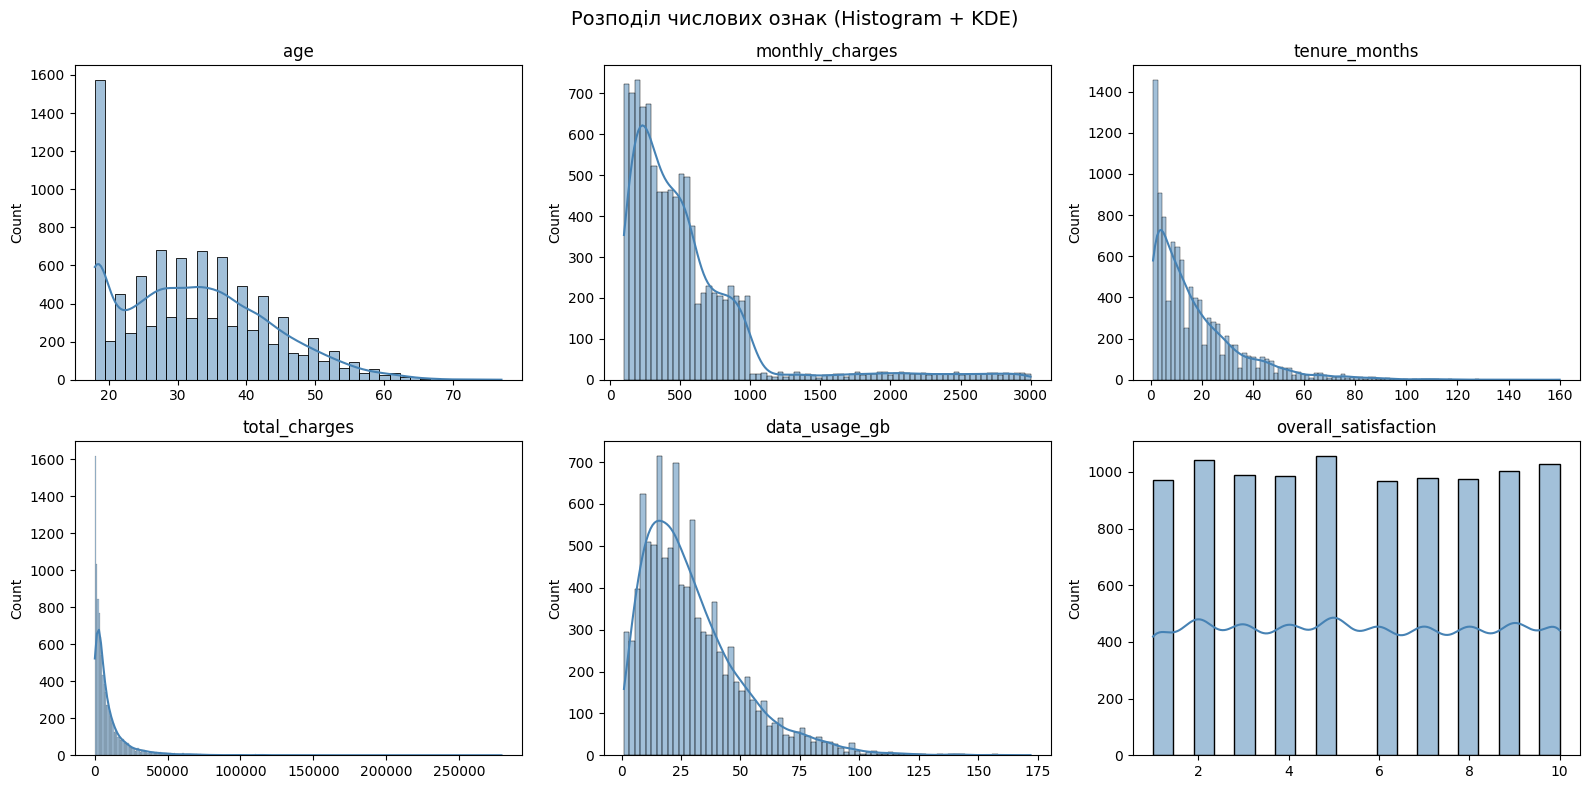

In [64]:
# Код побудови Histogram + KDE
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
fig.suptitle('Розподіл числових ознак (Histogram + KDE)', fontsize=14)

cols = ['age', 'monthly_charges', 'tenure_months',
        'total_charges', 'data_usage_gb', 'overall_satisfaction']

for ax, col in zip(axes.flatten(), cols):
    sns.histplot(df_customer_viz[col], kde=True, ax=ax, color='steelblue')
    ax.set_title(col)
    ax.set_xlabel('')

plt.tight_layout()
plt.show()

## Висновки Histogram + KDE

- `age`: розподіл близький до нормального, пік на 25-35 роках
- `monthly_charges`: рівномірний розподіл з правим хвостом — є клієнти з дуже високими платежами
- `tenure_months`: сильна права асиметрія — більшість клієнтів нові (до 12 місяців)
- `total_charges`: сильна права асиметрія — логарифмування доречне
- `data_usage_gb`: рівномірний розподіл з правим хвостом
- `overall_satisfaction`: рівномірний розподіл по всіх рівнях задоволеності

### Boxplot + Violin по групах


/tmp/ipykernel_4102/3367985669.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_customer_viz, x='churn', y='monthly_charges', ax=axes[0], palette='Set2')
/tmp/ipykernel_4102/3367985669.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_customer_viz, x='churn', y='tenure_months', ax=axes[1], palette='Set2')


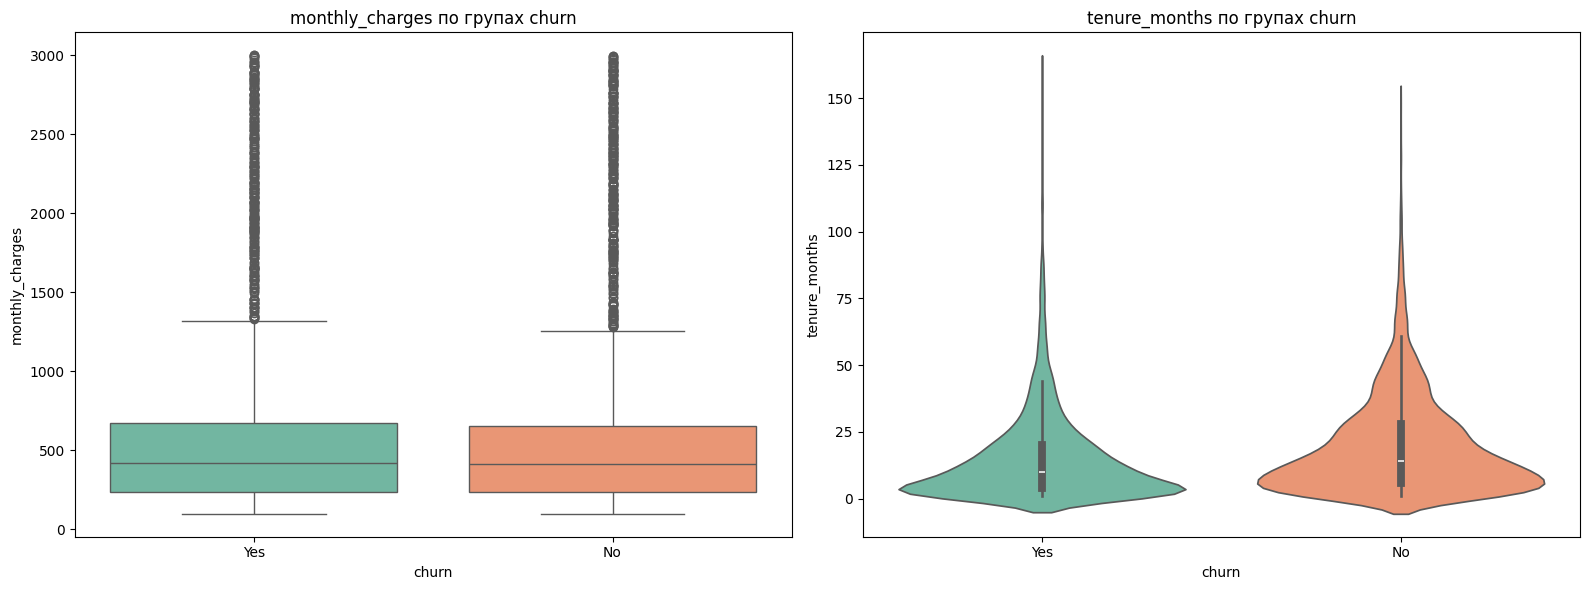

In [65]:
# Код побудови Boxplot + Violin
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Boxplot: monthly_charges по churn
sns.boxplot(data=df_customer_viz, x='churn', y='monthly_charges', ax=axes[0], palette='Set2')
axes[0].set_title('monthly_charges по групах churn')

# Violin: tenure_months по churn
sns.violinplot(data=df_customer_viz, x='churn', y='tenure_months', ax=axes[1], palette='Set2')
axes[1].set_title('tenure_months по групах churn')

plt.tight_layout()
plt.show()

## Висновки Boxplot + Violin

- `monthly_charges`: клієнти з відтоком (Yes) мають вищі місячні платежі — дорожчі тарифи підвищують ризик відтоку
- `tenure_months`: клієнти без відтоку мають більший стаж — довгострокові клієнти лояльніші
- Обидві ознаки є важливими предикторами відтоку

### Bar chart: частоти категорій / штатів / статусів


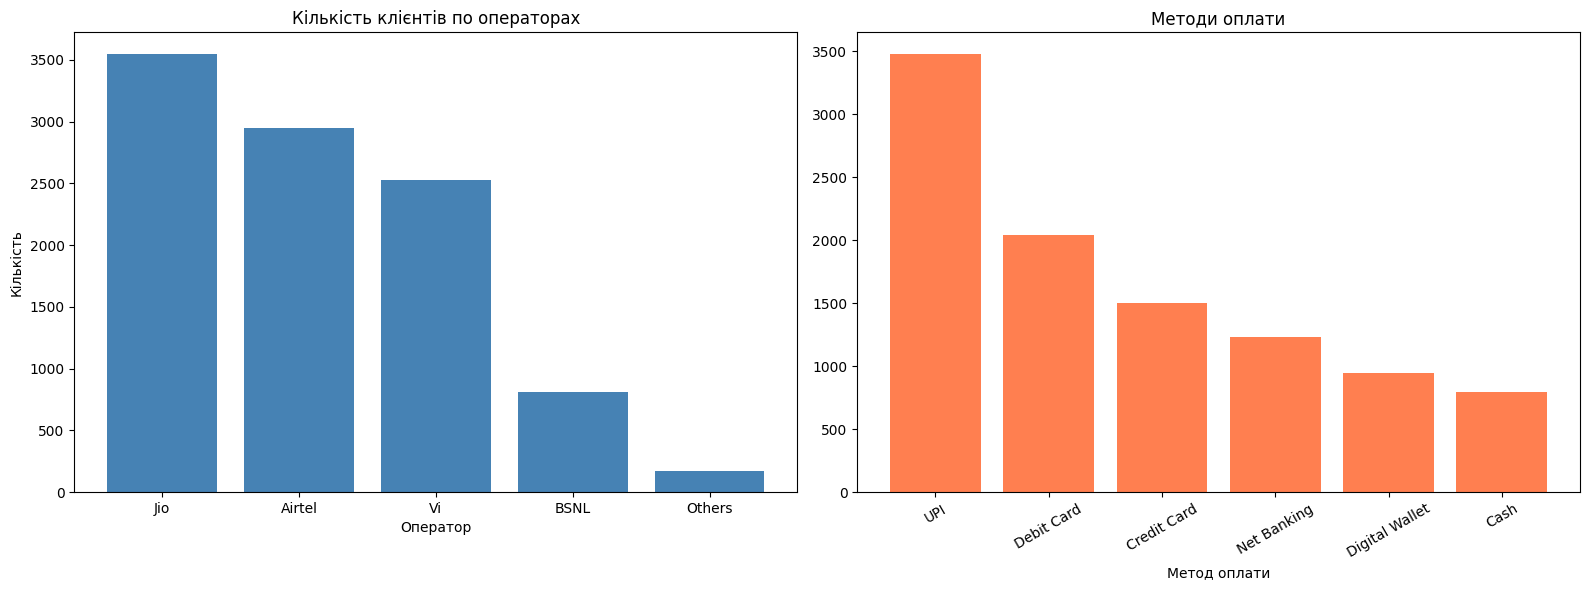

In [66]:
# Код побудови Bar chart
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Оператори
operator_counts = df_customer_viz['operator'].value_counts()
axes[0].bar(operator_counts.index, operator_counts.values, color='steelblue')
axes[0].set_title('Кількість клієнтів по операторах')
axes[0].set_xlabel('Оператор')
axes[0].set_ylabel('Кількість')

# Метод оплати
payment_counts = df_customer_viz['payment_method'].value_counts()
axes[1].bar(payment_counts.index, payment_counts.values, color='coral')
axes[1].set_title('Методи оплати')
axes[1].set_xlabel('Метод оплати')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

## Висновки Bar chart

- Клієнти розподілені між операторами відносно рівномірно — немає явного домінування одного оператора
- Методи оплати також розподілені рівномірно між основними способами
- Це свідчить про збалансований датасет без сильного зміщення по категоріях

### 100% Stacked bar: структура часток у групах


/tmp/ipykernel_4102/1682301532.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  pivot = df_customer_viz.groupby(['tenure_bucket', 'churn']).size().unstack(fill_value=0)


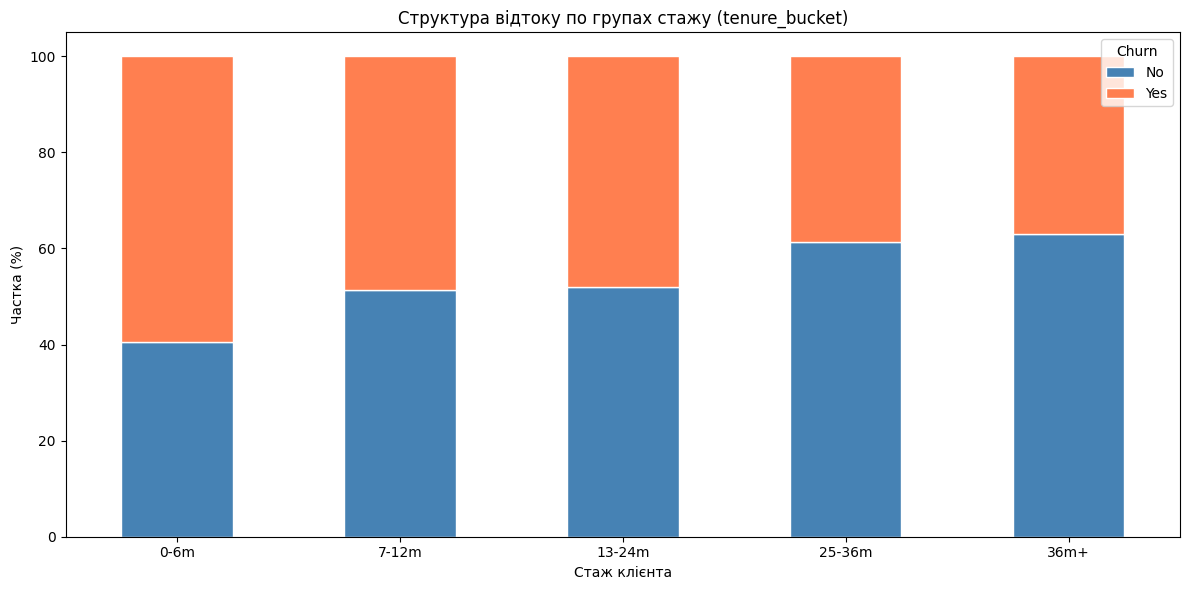


Частки churn по tenure_bucket (%):
churn            No   Yes
tenure_bucket            
0-6m           40.6  59.4
7-12m          51.4  48.6
13-24m         51.9  48.1
25-36m         61.4  38.6
36m+           62.9  37.1


In [67]:
# Код побудови 100% Stacked bar
pivot = df_customer_viz.groupby(['tenure_bucket', 'churn']).size().unstack(fill_value=0)
pivot_pct = pivot.div(pivot.sum(axis=1), axis=0) * 100

pivot_pct.plot(kind='bar', stacked=True, figsize=(12, 6),
               color=['steelblue', 'coral'], edgecolor='white')
plt.title('Структура відтоку по групах стажу (tenure_bucket)')
plt.xlabel('Стаж клієнта')
plt.ylabel('Частка (%)')
plt.legend(title='Churn', loc='upper right')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print("\nЧастки churn по tenure_bucket (%):")
print(pivot_pct.round(1))

## Висновки 100% Stacked bar

- Нові клієнти (0-6м) мають найвищий рівень відтоку — найбільш вразлива група
- Зі збільшенням стажу частка відтоку зменшується — довгострокові клієнти лояльніші
- Клієнти зі стажем 36м+ мають найнижчий рівень відтоку — сегмент найвищої лояльності
- Перші 6 місяців є критичним періодом для утримання клієнтів

### Scatter plot: зв’язки між числовими змінними


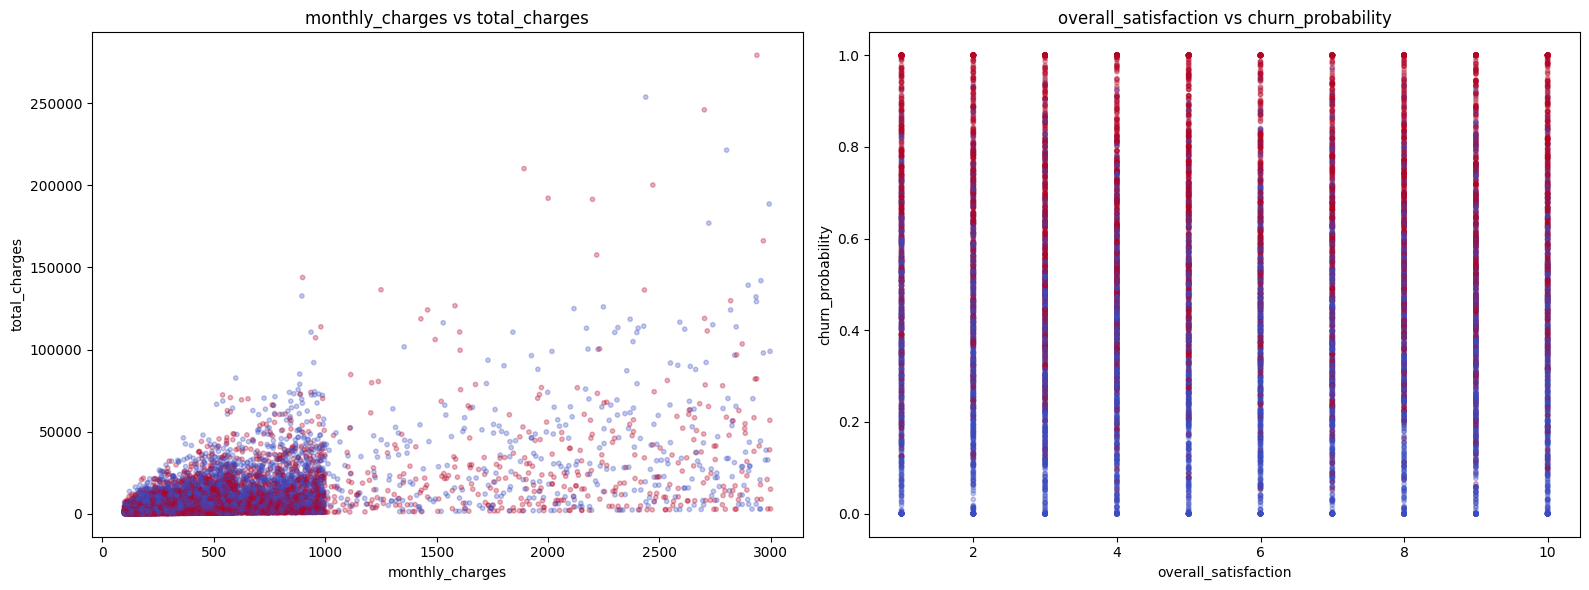

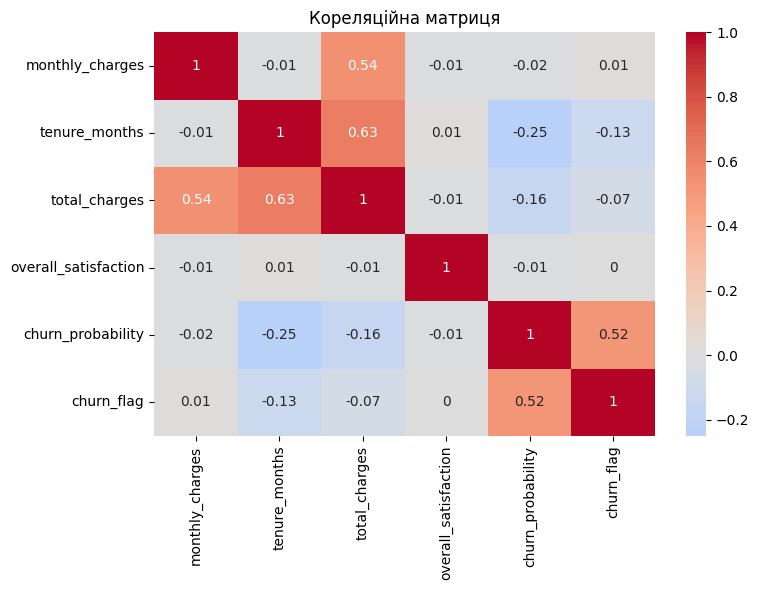

In [68]:
# Код побудови 100% Scatter plot:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# monthly_charges vs total_charges
axes[0].scatter(df_customer_viz['monthly_charges'],
                df_customer_viz['total_charges'],
                c=df_customer_viz['churn_flag'],
                cmap='coolwarm', alpha=0.3, s=10)
axes[0].set_title('monthly_charges vs total_charges')
axes[0].set_xlabel('monthly_charges')
axes[0].set_ylabel('total_charges')

# overall_satisfaction vs churn_probability
axes[1].scatter(df_customer_viz['overall_satisfaction'],
                df_customer_viz['churn_probability'],
                c=df_customer_viz['churn_flag'],
                cmap='coolwarm', alpha=0.3, s=10)
axes[1].set_title('overall_satisfaction vs churn_probability')
axes[1].set_xlabel('overall_satisfaction')
axes[1].set_ylabel('churn_probability')

plt.tight_layout()
plt.show()

# Кореляційна матриця
corr_cols = ['monthly_charges', 'tenure_months', 'total_charges',
             'overall_satisfaction', 'churn_probability', 'churn_flag']
corr = df_customer_viz[corr_cols].corr().round(2)
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0)
plt.title('Кореляційна матриця')
plt.tight_layout()
plt.show()

## Висновки Scatter plot

- `monthly_charges` vs `total_charges`: сильна позитивна кореляція — очікуваний результат
- `overall_satisfaction` vs `churn_probability`: негативна кореляція — вища задоволеність = менший ризик відтоку
- Клієнти з високою `churn_probability` (червоні точки) концентруються в зоні низької задоволеності
- Кореляційна матриця підтверджує: `churn_flag` найбільше корелює з `churn_probability` та негативно з `overall_satisfaction`

### Repeat rate by time window (30/60/90 days)

У e-commerce “repeat rate” — це повторні покупки за 30/60/90 днів. Ми робили такий графік для попереднього набору даних.

У Telco більш природний аналог — **ранній відтік**:

- churn_rate серед клієнтів із tenure ≤ 1 / 2 / 3 місяці (≈ 30/60/90 днів),
- частка таких клієнтів у датасеті.

Це дає уявлення про те, чи є проблема “early churn”.


=== EARLY CHURN АНАЛІЗ ===

Відтік серед клієнтів до 6 місяців: 59.4% (3152 клієнтів)
Відтік серед клієнтів до 12 місяців: 55.2% (5139 клієнтів)
Відтік серед клієнтів до 24 місяців: 52.9% (7524 клієнтів)


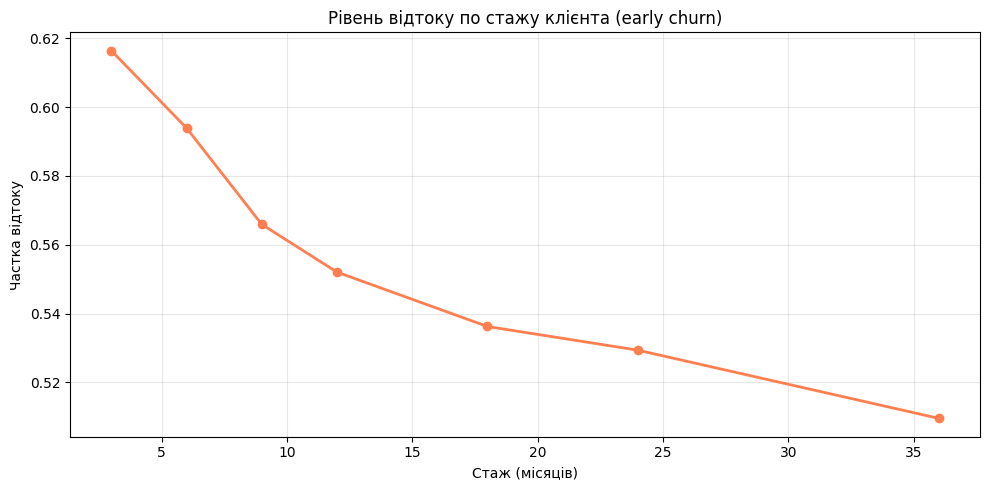

In [69]:
# Код побудови “early churn”.
# Early churn: частка клієнтів що пішли в перші N місяців
print("=== EARLY CHURN АНАЛІЗ ===\n")

for window in [6, 12, 24]:
    early = df_customer_viz[df_customer_viz['tenure_months'] <= window]
    churn_rate = early['churn_flag'].mean()
    print(f"Відтік серед клієнтів до {window} місяців: {churn_rate:.1%} ({len(early)} клієнтів)")

# Візуалізація
windows = [3, 6, 9, 12, 18, 24, 36]
rates = [df_customer_viz[df_customer_viz['tenure_months'] <= w]['churn_flag'].mean()
         for w in windows]

plt.figure(figsize=(10, 5))
plt.plot(windows, rates, marker='o', color='coral', linewidth=2)
plt.title('Рівень відтоку по стажу клієнта (early churn)')
plt.xlabel('Стаж (місяців)')
plt.ylabel('Частка відтоку')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Висновки Early Churn

- Клієнти з малим стажем мають найвищий рівень відтоку — перші місяці є критичними
- Зі збільшенням стажу рівень відтоку поступово знижується
- Це підтверджує важливість програм утримання нових клієнтів в перші 6-12 місяців

### Pareto chart (20/80)


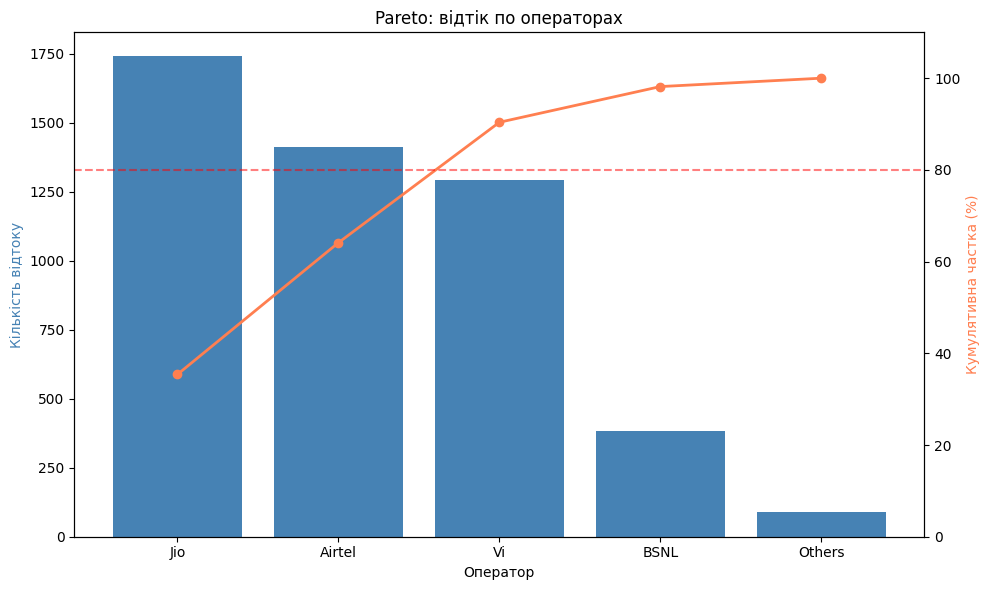

=== АНАЛІЗ PARETO ===
  Jio: кумулятивно 35.4%
  Airtel: кумулятивно 64.1%
  Vi: кумулятивно 90.4%
  BSNL: кумулятивно 98.2%
  Others: кумулятивно 100.0%


In [70]:
# Код побудови Pareto chart (20/80)
operator_churn = df_customer_viz.groupby('operator')['churn_flag'].sum().sort_values(ascending=False)
cumulative = (operator_churn.cumsum() / operator_churn.sum() * 100)

fig, ax1 = plt.subplots(figsize=(10, 6))

ax1.bar(operator_churn.index, operator_churn.values, color='steelblue')
ax1.set_xlabel('Оператор')
ax1.set_ylabel('Кількість відтоку', color='steelblue')

ax2 = ax1.twinx()
ax2.plot(operator_churn.index, cumulative.values, color='coral', marker='o', linewidth=2)
ax2.axhline(80, color='red', linestyle='--', alpha=0.5, label='80%')
ax2.set_ylabel('Кумулятивна частка (%)', color='coral')
ax2.set_ylim(0, 110)

plt.title('Pareto: відтік по операторах')
plt.tight_layout()
plt.show()

print("=== АНАЛІЗ PARETO ===")
for op, pct in cumulative.items():
    print(f"  {op}: кумулятивно {pct:.1f}%")

## Висновки Pareto

- Відтік розподілений між операторами відносно рівномірно — принцип 80/20 не виражений
- Немає одного оператора який би домінував у відтоку
- Це свідчить що причина відтоку не пов'язана з конкретним оператором а є системною проблемою

#  Загальні висновки: Модуль 2 — Аналітика клієнтських даних

## 1. Що аналізували
Датасет **Indian Telecom Customer Churn** — 10 000 клієнтів індійського телеком-оператора з 39 ознаками. Мета — виявити фактори відтоку клієнтів та підготувати дані для ML моделей.

## 2. Ключові знахідки

- **Датасет збалансований**: 49.2% відтоку — ідеально для ML без oversampling
- **Нові клієнти у зоні ризику**: 32% клієнтів мають стаж до 6 місяців і найвищий рівень відтоку
- **Задоволеність — ключовий фактор**: негативна кореляція між `overall_satisfaction` та `churn_probability`
- **Вищі платежі = більший ризик**: клієнти з відтоком мають вищі `monthly_charges`
- **Оператор не впливає**: відтік рівномірний між операторами — проблема системна
- **85% клієнтів на prepaid**: більшість користується передоплатними тарифами
- **95% мають інтернет**: майже вся база користується інтернет-послугами

## 3. Обмеження даних

- Датасет синтетичний — розподіли можуть не відповідати реальним даним
- Відсутня інформація про причини відтоку (скарги, конкуренти)
- Немає часових міток для аналізу динаміки

## 4. Наступні кроки

- **ML модель**: побудова класифікатора відтоку (Random Forest, XGBoost)
- **RFM сегментація**: виділення груп клієнтів за активністю та витратами
- **Аналіз перших 6 місяців**: детальне дослідження причин раннього відтоку
- **A/B тестування**: перевірка ефективності програм утримання нових клієнтів